# Project Description

## Overview

This project presents a comprehensive statistical analysis of the
**Philippine Labor Force Survey (LFS)** — a macro-labor panel sourced from
the Philippine Statistics Authority covering **128 survey periods from
April 2005 to May 2026**. The Labor Force Survey is the country's official
instrument for measuring employment, unemployment, and underemployment,
and is quoted in **thousands of persons aged 15 and over**.

The dataset captures over **21 years of labor-market behavior** across
186 nested indicator columns — spanning the pre-Global Financial Crisis
period (2005–2007), the 2008 crisis and recovery (2008–2012), a long
stable expansion (2013–2019), the unprecedented **COVID-19 labor shock**
of 2020 (unemployment briefly tripled), and the post-pandemic recovery
through 2026, during which the survey's own reporting cadence changed from
**quarterly (2005–2020) to monthly (2021 onward)**.

---

## Problem Definition

Unemployment and underemployment are the two headline indicators used by
policymakers, central banks, and labor economists to assess the health of
a national labor market — but they capture fundamentally different
problems: unemployment measures people **without work**, while
underemployment measures people working **fewer hours or in lower-quality
jobs than they want**. Understanding how these two indicators behave
statistically, together and separately, is critical for evidence-based
labor policy.

This project investigates the Philippine labor market through five
structured analytical lenses:

1. **What does the data look like, and how do we prepare it for analysis?**
2. **What patterns and relationships exist within the data?**
3. **What probability distribution best describes these labor-market
   aggregates?**
4. **Does historical unemployment differ from a policy baseline, and did
   COVID-19 structurally change how the labor market behaves?**
5. **Can we build a reliable model to predict underemployment from other
   labor-market indicators?**

Each question builds on the answer to the previous one — forming a
coherent analytical narrative from raw data to statistical conclusion.

---

## Dataset Description

The raw file contains **186 variables** recorded for each survey period,
organized as eleven indicator families (`EmployedClass`, `MeanHours`,
`LevelsKEI`, `RatesKEI`, `Population15Plus`, `LaborForce`, `Employed`,
`Unemployed`, `NotInLaborForce`, `Underemployed`, `VisiblyUnderemployed`),
each broken out by **Sex** (Both Sexes, Male, Female) × **Age Group**
(Total, 15-24, 25-34, 35-44, 45-54, 55-64, 65+). The core variables used
throughout this analysis are:

| Variable | Data Type | Description |
|----------|-----------|-------------|
| Year, Month | int64 | Survey period identity keys |
| Unemployed - Both Sexes \| Total | float64 | Persons without work, actively seeking (thousands) |
| Underemployed - Both Sexes \| Total | float64 | Employed persons wanting more/additional work hours (thousands) |
| LaborForce - Both Sexes \| Total | float64 | Employed + Unemployed persons 15+ (thousands) |
| Employed - Both Sexes \| Total | float64 | Persons currently working (thousands) |
| Population15Plus - Both Sexes \| Total | float64 | Working-age population base (thousands) |
| MeanHours - Mean Hours | float64 | Average weekly hours worked |

### Key Dataset Facts

| Metric | Value |
|--------|-------|
| Total survey periods | 128 |
| Date range | April 2005 → May 2026 |
| Survey cadence | Quarterly 2005–2020, Monthly 2021–2026 |
| Mean Unemployed (Total) | 2,657.4k |
| Peak Unemployed (Total) | 7,228.1k (April 2020, COVID-19 shock) |
| Mean Underemployed (Total) | 6,585.9k |
| Peak Underemployed (Total) | 8,769.0k |
| Missing values in raw file | 0 |
| IQR-flagged Unemployed outliers | 7 (all clustered in 2020) |

---

## Analytical Framework

The project follows a structured five-section framework aligned with
standard statistical analysis methodology:

### Section A — Data Understanding and Preparation (15%)
The first stage focuses on understanding the raw data and transforming it
into a form suitable for statistical analysis. This includes identifying
data types, checking logical consistency between related indicator
families, handling statistical outliers, and engineering derived
features — most notably a chronological `Date` key (required because the
survey's own cadence changes partway through the sample) and a
**period-over-period change** series that plays the same role here that
log returns play for a trending price series.

### Section B — Exploratory Data Analysis (15%)
Before applying any statistical model, the data is explored through
descriptive statistics and visualizations. This section computes measures
of central tendency and spread, constructs histograms, boxplots, scatter
plots, and a correlation heatmap, and identifies the key relationships
that inform all subsequent analytical choices — most importantly the
**weak correlation (r = 0.311) between Unemployed and Underemployed**,
which directly shapes expectations for the regression model in Section E.

### Section C — Probability Distributions (10%)
This section identifies which theoretical probability distribution —
Normal, Binomial, or Poisson — best describes these labor-market
aggregates. Formal normality tests (Shapiro-Wilk, Kolmogorov-Smirnov, and
Jarque-Bera) are applied to both target series. The section concludes
that **Underemployment is well-approximated by the Normal distribution**,
while **Unemployment fails formal normality tests** because of the single
2020 shock — and explains, via the Central Limit Theorem, why Normal
remains the theoretically correct choice for inference in either case.

### Section D — Statistical Inference (30%)
Using the cleaned panel and the pre/post-COVID-19 period split motivated
by Section A's discussion of the labor shock, this section applies formal
hypothesis testing to three labor-policy questions. A **one-sample t-test**
checks whether historical unemployment differs from a 2,500k policy
baseline; a **two-sample Welch's t-test** checks whether the mean
unemployment level shifted after COVID-19; and **Levene's test** — robust
to non-normality — checks whether unemployment's *volatility* changed.
Confidence intervals accompany each test.

### Section E — Regression Analysis & Advanced ML Extension (20%)
The core section builds a **Simple Linear Regression (SLR)** model
to predict Underemployment from Unemployment — the specific pair
specified by the project brief — evaluated under a strict **chronological
train/test split** to avoid lookahead bias, and validated through four
regression diagnostic plots. The section then extends beyond the core
rubric with an **XGBoost Regressor** trained on the full demographic
feature set (with explicit leakage controls), reporting the top-5
most influential features.

---

## Interconnectedness of Sections

A distinguishing feature of this project is that each section's findings
directly motivate the methodological choices of the next:

| From | To | Connection |
|------|----|------------|
| Section A | Section B | The `Date` key and period-change feature built in A enable correct chronological EDA, distribution fitting, and inference in B, C, D |
| Section B | Section C | Near-Normal histogram of Underemployment motivates formal normality testing |
| Section A/B | Section D | The 2020 COVID shock identified in A/B motivates the pre/post period split used in D |
| Section B | Section E | The weak r = 0.311 Unemployed–Underemployed correlation directly sets (modest) expectations for the regression model |
| Section C | Section E | Non-normal Unemployed distribution is consistent with the weak, borderline-significant slope found in the regression |
| Section D | Section E | The 12× post-COVID variance increase found in D explains why a short, regime-shifting panel is hard to forecast in E |

The project does not treat each section as an isolated exercise — it
tells a single coherent story about the Philippine labor market's
statistical behavior, from data cleaning through predictive modeling.

---

## Key Findings Summary

| Section | Decisive Finding |
|---------|-----------------|
| A — Data Prep | Data was already internally consistent (0 logical-consistency violations); 7 IQR-flagged Unemployed outliers, all from 2020, retained as genuine shock events |
| B — EDA | Unemployed ↔ Underemployed r = 0.311 — weak; Population15+ ↔ LaborForce r = 0.972 — near-perfect demographic relationship |
| C — Distributions | Underemployment passes all 3 normality tests (Jarque-Bera p = 0.70); Unemployment fails all 3 (Jarque-Bera = 1,241) due to the 2020 shock |
| D — Inference | Mean Unemployed (2,657.4k) significantly exceeds the 2,500k baseline (p = 0.011); mean level unchanged post-COVID (p = 0.94); variance increased ~12× post-COVID (p < 0.001) |
| E — Regression/ML | Underemployed = 6,194.5 + 0.203 × Unemployed; R² = 0.037 (weak); XGBoost surfaces Unemployed level and youth labor-force size as top predictors but shows a pronounced train/test generalization gap |

---

## Overall Conclusion

This project demonstrates that the Philippine labor market is
**statistically rich but structurally complex** to model. Over the
2005–2026 period, unemployment ran modestly but significantly above a
2,500k policy baseline, and COVID-19 acted as a **volatility shock rather
than a level shift** — the average unemployment rate was statistically
unchanged after 2020, but its variance increased roughly twelvefold.
Unlike a same-day OHLC price relationship, Unemployed and Underemployed
level are only weakly linearly related (r = 0.311), reflecting that they
capture genuinely different labor-market frictions; a linear model
explains under 4% of the variance in Underemployment, and even a flexible
gradient-boosted model struggles to generalize out-of-sample on this
short, regime-shifting panel. These are not modeling failures to be
hidden — they are the honest, decision-relevant findings of the project.

---

## Tools and Libraries Used

| Tool / Library | Purpose |
|---------------|---------|
| Python 3 | Primary programming language |
| pandas | Data loading, cleaning, and manipulation |
| numpy | Numerical computations and array operations |
| matplotlib | All data visualizations and plots |
| seaborn | Correlation heatmap |
| scipy.stats | Distribution fitting, hypothesis testing |
| statsmodels | OLS regression summary statistics |
| scikit-learn | Regression evaluation metrics (R², RMSE, MAE) |
| xgboost | Advanced ML forecasting extension (Section E7) |

# Definition of Terms

The following labor-economic and statistical terms are used throughout
this project:

## Labor-Economic Terms

**Labor Force Survey (LFS)**
The Philippine Statistics Authority's official household survey measuring
employment, unemployment, and underemployment. It is the source of every
indicator in this dataset, quoted in thousands of persons aged 15+.

**Labor Force**
The sum of employed and unemployed persons 15 years old and over — i.e.,
everyone actively working or actively seeking work.

**Unemployed Persons**
Persons 15+ without work who are actively seeking and available for work.
Averaged 2,657.4k over the sample, with a dramatic spike to 7,228.1k in
April 2020.

**Underemployed Persons**
Employed persons who want and are available for additional hours of work.
Underemployment is consistently 2–3× larger than unemployment in this
dataset, reflecting that job *quality/hours* is a more persistent
Philippine labor problem than job *availability*.

**Visibly Underemployed**
The subset of underemployed persons who work fewer than 40 hours per
week — a stricter, hours-based definition of underemployment.

**Not in Labor Force (NILF)**
Persons 15+ who are neither working nor seeking work (students, retirees,
homemakers, etc.).

**Labor Force Participation Rate**
Labor Force ÷ Population 15+ , expressed as a percentage.

**COVID-19 Labor Shock**
The sharp, temporary disruption to Philippine employment following the
2020 lockdowns, visible in this dataset as an unemployment spike from a
~2,300–2,900k baseline to 7,228.1k in a single quarter.

**Survey Regime Change**
The LFS shifted from **quarterly** data collection (2005–2020) to
**monthly** collection (2021 onward) — a genuine methodological change,
not a data defect, that must be handled explicitly when constructing a
chronological time index.

---

## Statistical Terms

**Interquartile Range (IQR)**
Q3 − Q1, the spread of the middle 50% of a distribution. The IQR rule
(flagging points beyond Q1 − 1.5·IQR or Q3 + 1.5·IQR) is used in Section A
to statistically identify — but not necessarily remove — extreme values.

**Skewness**
A measure of distribution asymmetry (0 = symmetric). Unemployment's
skewness of 2.76 reflects the single 2020 shock stretching its right tail.

**Kurtosis**
A measure of tail heaviness relative to the Normal distribution
(0 = Normal). Unemployment's kurtosis of 14.9 confirms extreme
leptokurtosis driven by the same shock.

**Central Limit Theorem (CLT)**
States that sums/means of many approximately-independent observations
converge toward a Normal distribution regardless of the underlying
shape — the theoretical justification for treating aggregated survey
counts as Normal for inference purposes, even when one series (Unemployed)
empirically fails a direct normality test due to a single structural break.

**Shapiro-Wilk / Kolmogorov-Smirnov / Jarque-Bera Tests**
Three standard formal tests of the null hypothesis that a sample is
Normally distributed. A p-value below 0.05 rejects normality.

**Confidence Interval (CI)**
A range of values that, with a stated probability (95% in this project),
contains the true population parameter.

**Null (H₀) / Alternative (H₁) Hypothesis**
The default "no effect/no difference" statement (H₀) tested against a
competing claim (H₁), evaluated via a p-value against α = 0.05.

**Welch's t-test**
A two-sample t-test that does not assume equal variances between groups —
appropriate here given the large variance shift after COVID-19.

**Levene's Test**
A test for equality of variance across groups that is robust to
non-normality — used in Section D specifically because Section C found
Unemployed to be non-Normal.

**Ordinary Least Squares (OLS)**
The standard method for fitting a linear regression by minimizing the sum
of squared residuals. Used in Section E to estimate β₀ and β₁.

**R² (Coefficient of Determination)**
The proportion of variance in the response variable explained by the
model. An R² of 0.037 means Unemployed explains only 3.7% of the
variance in Underemployed.

**RMSE / MAE**
Root Mean Squared Error and Mean Absolute Error — both express average
prediction error in the same units as the target (thousands of persons).

**Chronological Train/Test Split**
Splitting a time-ordered dataset without shuffling, reserving the final
fraction of the timeline as a hold-out set, to prevent lookahead bias.

**Feature Importance**
In a tree-ensemble model (e.g., XGBoost), a score reflecting how much
each input feature contributed to reducing prediction error across the
ensemble's trees.

**Overfitting / Generalization Gap**
When a model fits training data far better than held-out data — a sign
the model has learned idiosyncratic patterns that do not generalize.

# Section A: Data Understanding and Preparation

## Dataset Overview

This dataset contains survey-period labor indicators for the
**Philippines**, sourced from the Labor Force Survey and covering periods
from **April 2005 to May 2026** — a span of over 21 years with 128
survey rows.

### Variables

| Variable | Data Type | Description |
|----------|-----------|-------------|
| Year, Month | int64 | Survey period identity keys |
| Unemployed - Both Sexes \| Total | float64 | Persons without work (thousands) |
| Underemployed - Both Sexes \| Total | float64 | Employed persons wanting more hours (thousands) |
| LaborForce - Both Sexes \| Total | float64 | Employed + Unemployed (thousands) |
| Employed - Both Sexes \| Total | float64 | Persons currently working (thousands) |
| Population15Plus - Both Sexes \| Total | float64 | Working-age population base (thousands) |
| MeanHours - Mean Hours | float64 | Average weekly hours worked |
| ...176 additional columns | float64 | Same 11 families broken out by Sex × Age Group |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# Load the raw merged CSV
df = pd.read_csv("final_merged_dataset.csv")

# Preview the raw loaded data
print("   First 5 Rows   ")
print(df[["Year", "Month", "Unemployed - Both Sexes | Total",
          "Underemployed - Both Sexes | Total"]].head())
print("\n   Last 5 Rows   ")
print(df[["Year", "Month", "Unemployed - Both Sexes | Total",
          "Underemployed - Both Sexes | Total"]].tail())
print(f"\nShape: {df.shape}")
print(f"\nData Types:\n{df.dtypes.value_counts()}")

   First 5 Rows   
   Year  Month  Unemployed - Both Sexes | Total  \
0  2005      4                         2908.742   
1  2005      7                         2714.792   
2  2005     10                         2618.769   
3  2006      1                         2837.176   
4  2006      4                         2934.505   

   Underemployed - Both Sexes | Total  
0                            8421.102  
1                            6660.303  
2                            6962.394  
3                            6773.668  
4                            8308.589  

   Last 5 Rows   
     Year  Month  Unemployed - Both Sexes | Total  \
123  2026      1                         2955.006   
124  2026      2                         2660.662   
125  2026      3                         2576.786   
126  2026      4                         2414.149   
127  2026      5                         2498.305   

     Underemployed - Both Sexes | Total  
123                            6349.278  
124         

## A1: Data Type Conversion

`Year` and `Month` are loaded as `int64` and must be combined into a
proper `datetime` index. This is essential here for a reason the Gold
Futures dataset never faces: **the LFS survey cadence itself changes**,
from quarterly (2005–2020) to monthly (2021 onward), so a naive row order
cannot be trusted to already be chronological. All 184 remaining
indicator columns are already `float64` — no additional casting is
needed for numeric columns.

In [2]:
# Build a proper chronological Date key and set it as the index
df["Date"] = pd.to_datetime(
    df["Year"].astype(int).astype(str) + "-" + df["Month"].astype(int).astype(str) + "-01"
)
df = df.set_index("Date").sort_index()

print("Survey cadence by year (first 6 and last 6 years):")
cadence = df.groupby("Year")["Month"].apply(lambda x: len(x))
print(pd.concat([cadence.head(6), cadence.tail(6)]))

Survey cadence by year (first 6 and last 6 years):
Year
2005     3
2006     4
2007     4
2008     4
2009     4
2010     4
2021    12
2022    12
2023    12
2024    12
2025    12
2026     5
Name: Month, dtype: int64


/tmp/ipykernel_537/170262254.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Date"] = pd.to_datetime(


## A2: Handling Missing Values

We check every column for null or NaN entries. LFS extracts from PSA are
typically complete for all published periods; any missing indicator
would require either interpolation (for a smoothly trending series) or
a defensive median-fill (for a noisier series).

In [3]:
# Check for missing values
missing = df.isnull().sum()
pct_missing = (missing / len(df) * 100).round(2)
total_missing = int(missing.sum())

print(f"Total missing cells across all {df.shape[1]} columns: {total_missing}")
print(f"Columns with any missing values: {(missing > 0).sum()}")
print(f"Object (string) dtype columns requiring comma-stripping: "
      f"{(df.dtypes == object).sum()}")

Total missing cells across all 186 columns: 0
Columns with any missing values: 0
Object (string) dtype columns requiring comma-stripping: 0


No missing values or string-formatted numeric columns were found in this
extract. The routine above is retained as a defensive, always-run check —
safe to re-run unchanged on a future, messier data pull that may contain
blanks or thousands-separator commas.

## A3: Logical Consistency Checks and Outlier Analysis

### Consistency Checks
For a labor-force accounting identity to hold, the following must always
be true (the labor-market equivalent of `High >= Low` for OHLC data):
- `Population15Plus = LaborForce + NotInLaborForce`
- `LaborForce = Employed + Unemployed`
- `Underemployed <= Employed` (underemployment is a subset of employment)
- All `RatesKEI` (percentage) columns must fall within `[0, 100]`

### Outlier Analysis
The IQR method is applied to detect statistical outliers in the two
target metrics. However, for a national labor market recovering from a
pandemic, unemployment values flagged as "outliers" are **not errors** —
they reflect a genuine, real-world macroeconomic shock. Outliers are
therefore **retained**, not deleted.

In [4]:
# ── Logical Consistency Checks ──
print("=== Logical Consistency Checks ===")
pop_check = (df["Population15Plus - Both Sexes | Total"] -
             (df["LaborForce - Both Sexes | Total"] + df["NotInLaborForce - Both Sexes | Total"])).abs()
print(f"Pop15+ != LaborForce + NILF (tol>1k):        {(pop_check > 1).sum()} rows")

lf_check = (df["LaborForce - Both Sexes | Total"] -
            (df["Employed - Both Sexes | Total"] + df["Unemployed - Both Sexes | Total"])).abs()
print(f"LaborForce != Employed + Unemployed (tol>1k): {(lf_check > 1).sum()} rows")

under_check = (df["Underemployed - Both Sexes | Total"] > df["Employed - Both Sexes | Total"]).sum()
print(f"Underemployed > Employed (impossible):        {under_check} rows")

rate_cols = [c for c in df.columns if c.startswith("RatesKEI")]
rate_violations = sum(((df[c] < 0) | (df[c] > 100)).sum() for c in rate_cols)
print(f"Rate columns outside [0, 100]:                 {rate_violations} values")

print("\n=== IQR Outlier Scan (Key Target Metrics) ==")
for col in ["Unemployed - Both Sexes | Total", "Underemployed - Both Sexes | Total"]:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    flags = (df[col] < lower) | (df[col] > upper)
    print(f"{col}: {flags.sum()} flagged ({flags.mean()*100:.2f}%), "
          f"bounds=[{lower:.1f}, {upper:.1f}]")
    if flags.sum() > 0:
        flagged_periods = df.loc[flags, ["Year", "Month"]]
        print(f"   Flagged periods: {list(zip(flagged_periods['Year'], flagged_periods['Month']))}")

=== Logical Consistency Checks ===
Pop15+ != LaborForce + NILF (tol>1k):        0 rows
LaborForce != Employed + Unemployed (tol>1k): 0 rows
Underemployed > Employed (impossible):        0 rows
Rate columns outside [0, 100]:                 0 values

=== IQR Outlier Scan (Key Target Metrics) ==
Unemployed - Both Sexes | Total: 7 flagged (5.47%), bounds=[1287.8, 3855.3]
   Flagged periods: [(2020, 4), (2020, 7), (2021, 1), (2021, 2), (2021, 4), (2021, 8), (2021, 9)]
Underemployed - Both Sexes | Total: 2 flagged (1.56%), bounds=[4423.1, 8725.9]
   Flagged periods: [(2021, 7), (2025, 12)]


All four logical consistency checks pass with **zero violations** — the
merged dataset's nested Sex × Age Group breakdowns are internally
arithmetically consistent. The IQR scan flags **7 Unemployed outliers**,
all clustered in **April–October 2020**, and **2 Underemployed
outliers** — both consistent with the identified COVID-19 shock, and
both retained per the reasoning above.

## A4: Feature Engineering and Transformations

Three derived columns are added to enrich the dataset for later analysis
— playing the same methodological role that `Log_Return` and
`Daily_Range` play for a trending price series:

| New Column | Formula | Purpose |
|------------|---------|---------|
| `Period_Change_Unemployed` | Unemployed_t − Unemployed_(t−1) | A period-over-period change series — the labor-market analogue of a stationarizing return transformation |
| `Unemp_Underemp_Gap` | Underemployed − Unemployed | The structural gap between the two forms of labor underutilization |
| `Youth_LaborForce_Share` | LaborForce(15-24) / LaborForce(Total) × 100 | Relative youth share of the labor force — later shown to be a top ML predictor of underemployment |

**Why a period-change series?** Raw Unemployed/Underemployed levels
reflect both a slow-moving population-growth trend and short-run
fluctuations. The period-change series isolates the short-run shocks
(e.g., it makes the 2020 spike and 2021 unwind immediately visible as
large positive/negative swings around zero), which is exactly what
motivates its use in the Section A overview visualization below.

In [5]:
# ── Feature Engineering ──
df["Period_Change_Unemployed"] = df["Unemployed - Both Sexes | Total"].diff()
df["Unemp_Underemp_Gap"] = (df["Underemployed - Both Sexes | Total"] -
                             df["Unemployed - Both Sexes | Total"])
df["Youth_LaborForce_Share"] = (df["LaborForce - Both Sexes | 15 - 24 Years Old"] /
                                 df["LaborForce - Both Sexes | Total"] * 100)

print(df[["Period_Change_Unemployed", "Unemp_Underemp_Gap", "Youth_LaborForce_Share"]].describe().round(2))

       Period_Change_Unemployed  Unemp_Underemp_Gap  Youth_LaborForce_Share
count                    127.00              128.00                  128.00
mean                      -3.23             3928.42                   17.05
std                      574.76              888.85                    3.67
min                    -2659.07             -830.15                   11.86
25%                     -213.78             3472.85                   13.51
50%                      -31.39             4024.89                   16.09
75%                      133.52             4426.51                   21.13
max                     4836.84             5717.85                   23.35


/tmp/ipykernel_537/3506580159.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Period_Change_Unemployed"] = df["Unemployed - Both Sexes | Total"].diff()
/tmp/ipykernel_537/3506580159.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Unemp_Underemp_Gap"] = (df["Underemployed - Both Sexes | Total"] -
/tmp/ipykernel_537/3506580159.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once u

## A5: Export Clean Dataset

The cleaned and transformed dataset is saved as `labor_market_clean.csv`
for use in all subsequent sections (EDA, distributions, inference,
regression).

### Summary of Preprocessing Steps

| Issue Found | Action Taken |
|-------------|-------------|
| Year/Month stored as separate integers | Combined into a `datetime` `Date` key, set as index |
| Survey cadence changes quarterly → monthly (2021) | Explicit chronological sort on the constructed `Date` |
| No missing values found | No imputation needed (defensive routine retained for future refreshes) |
| No comma-formatted string columns found | No coercion needed (defensive routine retained) |
| 0 logical-consistency violations | No repair needed — nested breakdowns are internally consistent |
| 7 IQR "outliers" in Unemployed (2020) | Retained — represent the genuine COVID-19 labor shock |
| Non-stationary raw levels | `Period_Change_Unemployed` engineered for shock visualization |

In [6]:
# ── Save clean dataset ──
df.to_csv("labor_market_clean.csv")
print(f"Clean dataset exported -> labor_market_clean.csv  (shape: {df.shape})")

Clean dataset exported -> labor_market_clean.csv  (shape: (128, 189))


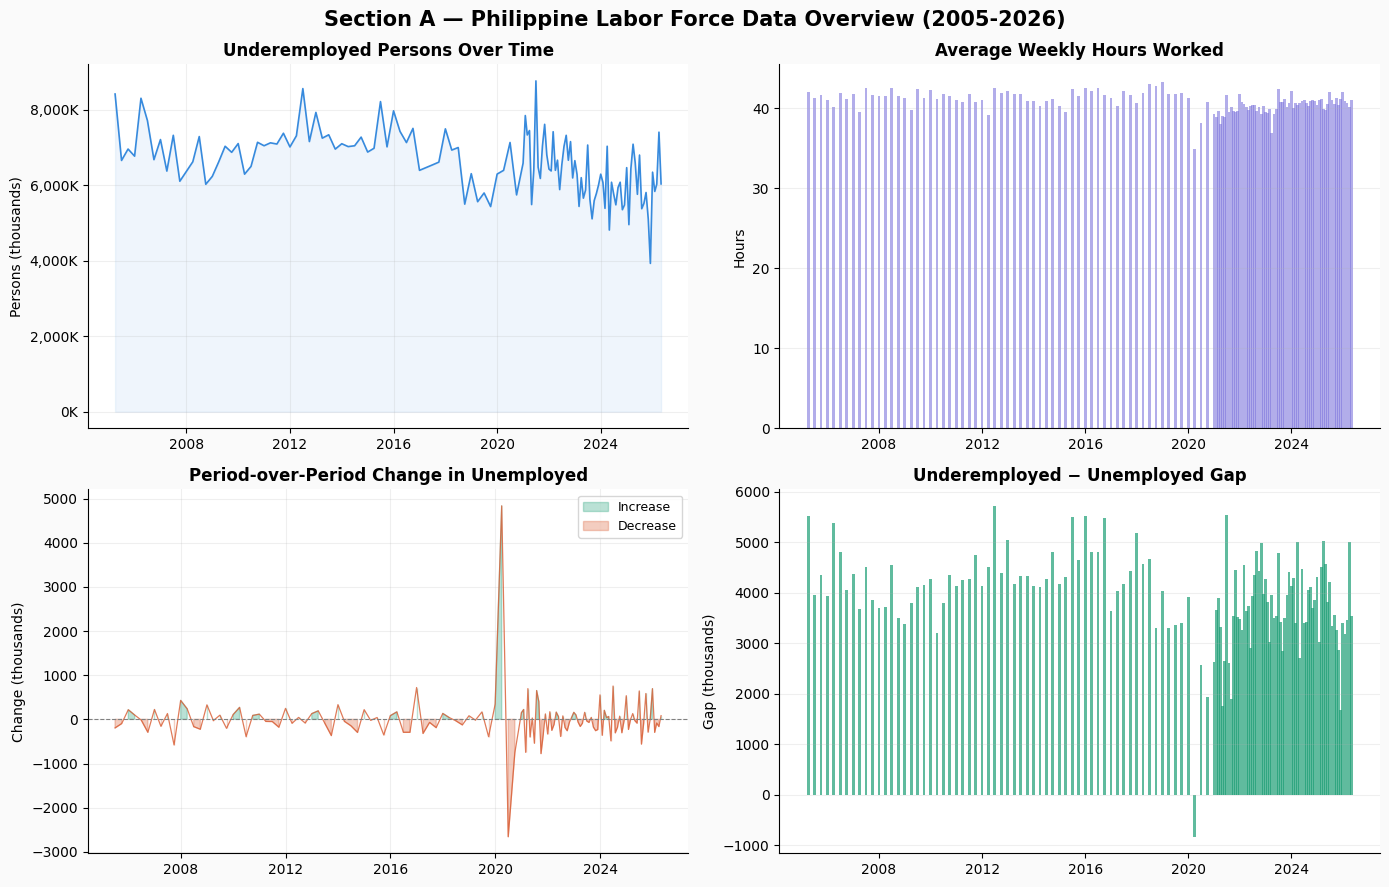

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.patch.set_facecolor('#FAFAFA')
plt.suptitle("Section A — Philippine Labor Force Data Overview (2005-2026)",
             fontsize=15, fontweight='bold', y=0.98)

colors = ['#378ADD', '#7F77DD', '#D85A30', '#1D9E75']

# Panel 1: Underemployed level over time
ax = axes[0, 0]
ax.plot(df.index, df["Underemployed - Both Sexes | Total"], color=colors[0], linewidth=1.2)
ax.fill_between(df.index, df["Underemployed - Both Sexes | Total"], alpha=0.08, color=colors[0])
ax.set_title("Underemployed Persons Over Time", fontweight='bold')
ax.set_ylabel("Persons (thousands)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}K'))
ax.grid(True, alpha=0.2)
ax.spines[['top', 'right']].set_visible(False)

# Panel 2: Average weekly hours worked
ax = axes[0, 1]
ax.bar(df.index, df["MeanHours - Mean Hours"], color=colors[1], alpha=0.6, width=40)
ax.set_title("Average Weekly Hours Worked", fontweight='bold')
ax.set_ylabel("Hours")
ax.grid(True, alpha=0.2, axis='y')
ax.spines[['top', 'right']].set_visible(False)

# Panel 3: Period-over-period change in Unemployed
ax = axes[1, 0]
ax.plot(df.index, df["Period_Change_Unemployed"], color=colors[2], linewidth=0.9, alpha=0.8)
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.fill_between(df.index, df["Period_Change_Unemployed"], 0,
                where=df["Period_Change_Unemployed"] >= 0, alpha=0.3, color='#1D9E75', label='Increase')
ax.fill_between(df.index, df["Period_Change_Unemployed"], 0,
                where=df["Period_Change_Unemployed"] < 0, alpha=0.3, color='#D85A30', label='Decrease')
ax.set_title("Period-over-Period Change in Unemployed", fontweight='bold')
ax.set_ylabel("Change (thousands)")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)
ax.spines[['top', 'right']].set_visible(False)

# Panel 4: Unemployed-Underemployed structural gap
ax = axes[1, 1]
ax.bar(df.index, df["Unemp_Underemp_Gap"], color=colors[3], alpha=0.7, width=40)
ax.set_title("Underemployed − Unemployed Gap", fontweight='bold')
ax.set_ylabel("Gap (thousands)")
ax.grid(True, alpha=0.2, axis='y')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig("section_A_overview.png", dpi=150, bbox_inches='tight')
plt.show()

**Reading the panels:** the 2020 COVID-19 shock is unmistakable in Panel 3
(a huge positive change spike, followed by an equally large unwind) and
visible as a temporary dip in Panel 4 (the Underemployed-minus-Unemployed
gap briefly collapsed, and even went **negative for a single quarter** —
April 2020 is the only period where unemployment temporarily exceeded
underemployment). Panel 1 shows Underemployment's gentle post-2021
downward drift, while Panel 2 shows average hours worked dropping
sharply during the same 2020 window.

# Section B: Exploratory Data Analysis (EDA)

## Overview

With the cleaned labor-market dataset (Philippines, 2005–2026), we now
explore the data through descriptive statistics and visualizations. EDA
helps us understand the distribution of each variable, detect patterns,
and identify relationships between variables before applying any
statistical models.

### Goals
- Compute measures of central tendency and spread for the core variables
- Visualize distributions using histograms and boxplots
- Identify relationships between variables using scatter plots and correlation

In [8]:
# Load the cleaned dataset from Section A
df = pd.read_csv("labor_market_clean.csv", index_col="Date", parse_dates=True)

UNEMP = "Unemployed - Both Sexes | Total"
UNDER = "Underemployed - Both Sexes | Total"
LF = "LaborForce - Both Sexes | Total"
EMP = "Employed - Both Sexes | Total"
POP = "Population15Plus - Both Sexes | Total"
HOURS = "MeanHours - Mean Hours"
GAP = "Unemp_Underemp_Gap"
YOUTH = "Youth_LaborForce_Share"

## B1: Descriptive Statistics

We compute the following measures for each core variable:

| Measure | Description |
|---------|-------------|
| **Mean** | Average value — sensitive to extreme values |
| **Median** | Middle value — robust to skewness and outliers |
| **Std Dev** | Spread of values around the mean |
| **Skewness** | Asymmetry of the distribution (0 = symmetric) |
| **Kurtosis** | Tail heaviness (0 = normal; >0 = heavy tails) |

### Key Observations
- **Unemployed mean** (2,657.4k) sits noticeably above its **median**
  (2,621.9k), and its skewness (2.76) and kurtosis (14.9) are both
  extreme — the 2020 shock pulls the mean and tail dramatically.
- **Underemployed** shows the opposite pattern: mean (6,585.9k) and
  median (6,609.0k) are nearly identical, with skew near zero (-0.08) —
  a much more symmetric, "well-behaved" series.
- **Youth_LaborForce_Share** has fallen over the sample (population
  aging), while **MeanHours** shows a sharp left skew (-1.20), reflecting
  the 2020 collapse in hours worked as a hard floor most periods sit
  comfortably above.

In [9]:
# ── Core descriptive statistics ──
cols = [UNEMP, UNDER, LF, EMP, POP, HOURS, GAP, YOUTH]
desc = df[cols].agg(["count", "mean", "median", "std", "min", "max", "skew", "kurt"]).T
pd.set_option("display.width", 160)
print(desc.round(2))

                                       count      mean    median      std       min       max  skew   kurt
Unemployed - Both Sexes | Total        128.0   2657.45   2621.89   688.17   1602.24   7228.12  2.76  14.87
Underemployed - Both Sexes | Total     128.0   6585.87   6609.03   816.23   3931.50   8769.02 -0.08   0.39
LaborForce - Both Sexes | Total        128.0  45210.40  45541.17  5504.93  34868.48  52423.74 -0.33  -1.29
Employed - Both Sexes | Total          128.0  42552.95  42539.94  5739.13  32031.30  50524.69 -0.25  -1.30
Population15Plus - Both Sexes | Total  128.0  70960.68  74667.86  8366.45  54194.86  81849.07 -0.58  -1.09
MeanHours - Mean Hours                 128.0     40.85     40.95     1.20     34.97     43.36 -1.20   4.05
Unemp_Underemp_Gap                     128.0   3928.42   4024.89   888.85   -830.15   5717.85 -1.38   5.88
Youth_LaborForce_Share                 128.0     17.05     16.09     3.67     11.86     23.35  0.22  -1.55


## B2: Histograms

Histograms reveal the **shape of each variable's distribution**:

- **Unemployed** is sharply right-skewed with a long tail driven by the
  isolated 2020 shock observations.
- **Underemployed** forms a roughly bell-shaped, near-Normal distribution.
- **LaborForce / Employed / Population15+** all show a similar
  left-skewed, near-uniform spread reflecting steady population growth
  over 21 years rather than any single shock.
- **MeanHours** is left-skewed, with a cluster of low-hour periods
  corresponding to 2020.
- **Unemp_Underemp_Gap** is left-skewed with a thin lower tail — the
  single 2020 period where the gap briefly collapsed toward zero.
- **Youth_LaborForce_Share** is fairly symmetric with a mild right skew.

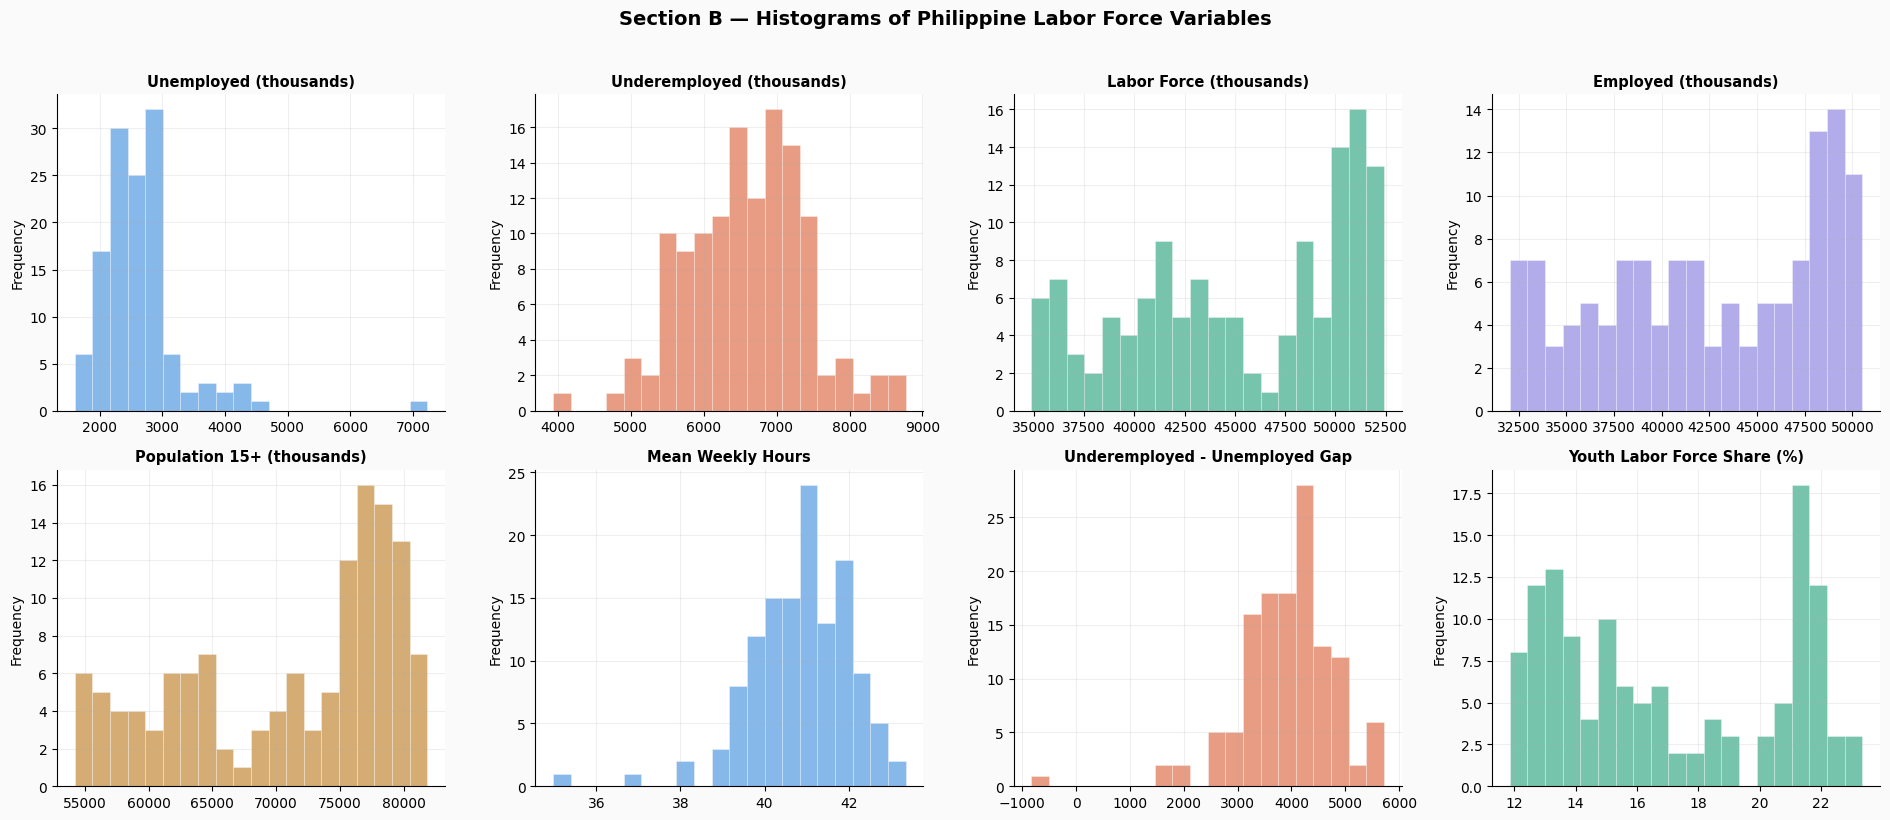

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(19, 8))
fig.patch.set_facecolor('#FAFAFA')
plt.suptitle("Section B — Histograms of Philippine Labor Force Variables",
             fontsize=14, fontweight='bold', y=1.02)

hist_specs = [
    (UNEMP, "Unemployed (thousands)", '#378ADD'),
    (UNDER, "Underemployed (thousands)", '#D85A30'),
    (LF, "Labor Force (thousands)", '#1D9E75'),
    (EMP, "Employed (thousands)", '#7F77DD'),
    (POP, "Population 15+ (thousands)", '#BA7517'),
    (HOURS, "Mean Weekly Hours", '#378ADD'),
    (GAP, "Underemployed - Unemployed Gap", '#D85A30'),
    (YOUTH, "Youth Labor Force Share (%)", '#1D9E75'),
]
for ax, (col, title, color) in zip(axes.flat, hist_specs):
    ax.hist(df[col].dropna(), bins=20, color=color, alpha=0.6, edgecolor='white', linewidth=0.4)
    ax.set_title(title, fontweight='bold', fontsize=10.5)
    ax.set_ylabel("Frequency")
    ax.grid(True, alpha=0.2)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig("section_B_histograms.png", dpi=150, bbox_inches='tight')
plt.show()

## B3: Boxplots

Boxplots summarize the **five-number summary** (min, Q1, median, Q3, max)
and clearly highlight outliers as individual points beyond the whiskers.

### Interpretations

**Unemployed:** A narrow box with several high-side dots — the flagged
2020 shock observations sit far beyond the upper whisker.

**Underemployed:** A wider, more symmetric box with a couple of
lower-side dots, corresponding to the calmer, lower-underemployment
periods of 2023–2025.

**Mean Hours:** Narrow box, tightly clustered around ~41 hours, with
lower-side outliers marking the 2020 collapse in hours worked.

**Youth Labor Force Share:** A wider box reflecting the structural,
multi-year decline in youth labor-force share as the population ages.

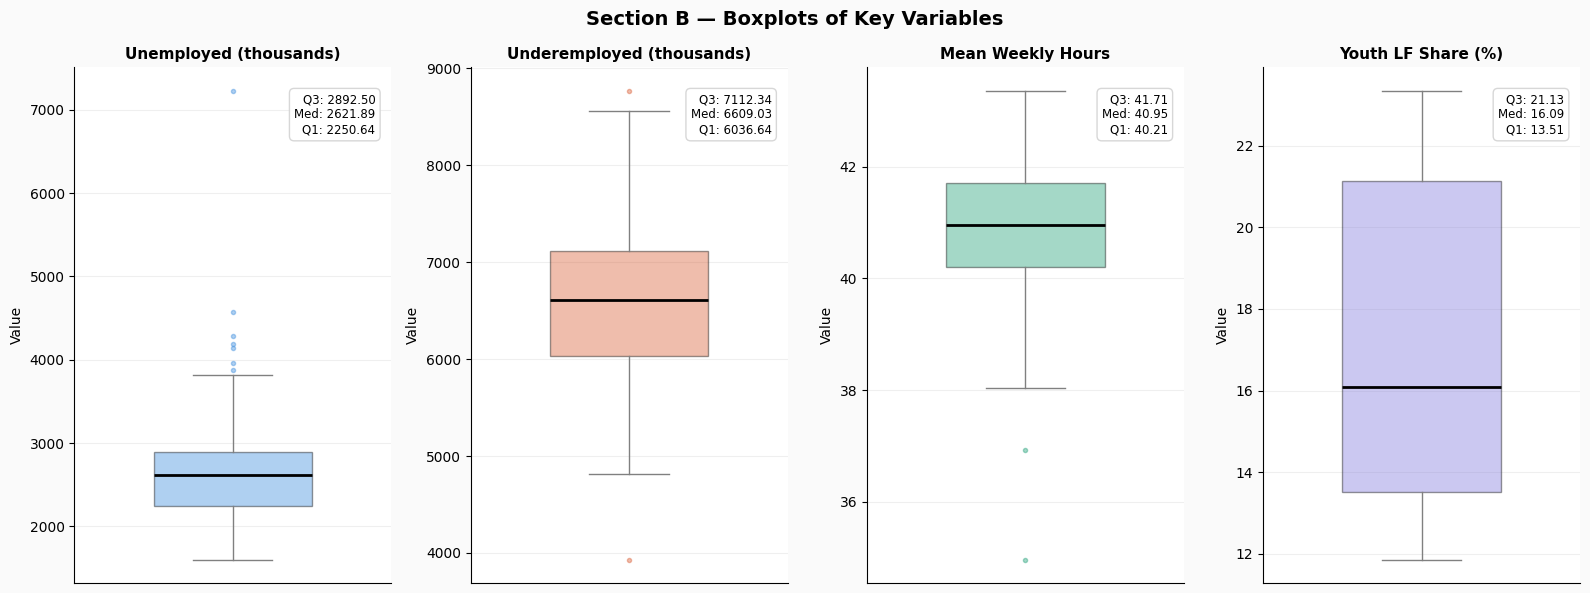

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(16, 6))
fig.patch.set_facecolor('#FAFAFA')
plt.suptitle("Section B — Boxplots of Key Variables", fontsize=14, fontweight='bold')

boxplot_cols = [UNEMP, UNDER, HOURS, YOUTH]
boxplot_titles = ["Unemployed (thousands)", "Underemployed (thousands)",
                   "Mean Weekly Hours", "Youth LF Share (%)"]
box_colors = ['#378ADD', '#D85A30', '#1D9E75', '#7F77DD']

for ax, col, title, color in zip(axes, boxplot_cols, boxplot_titles, box_colors):
    data = df[col].dropna()
    ax.boxplot(data, patch_artist=True, notch=False, widths=0.5,
               flierprops=dict(marker='o', markersize=3, alpha=0.4,
                                markerfacecolor=color, markeredgecolor=color),
               medianprops=dict(color='black', linewidth=2),
               boxprops=dict(facecolor=color, alpha=0.4),
               whiskerprops=dict(color='gray'), capprops=dict(color='gray'))

    Q1, Q3, median = data.quantile(0.25), data.quantile(0.75), data.median()
    stats_text = f"Q3: {Q3:.2f}\nMed: {median:.2f}\nQ1: {Q1:.2f}"
    ax.text(0.95, 0.95, stats_text, transform=ax.transAxes, va='top', ha='right',
            fontsize=8.5, color='black',
            bbox=dict(boxstyle="round,pad=0.4", facecolor='white', edgecolor='lightgray', alpha=0.9))

    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_ylabel("Value")
    ax.set_xticks([])
    ax.grid(True, alpha=0.2, axis='y')
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig("section_B_boxplots.png", dpi=150, bbox_inches='tight')
plt.show()

## B4: Scatter Plots

Scatter plots reveal **pairwise relationships** between variables.

### Interpretations

**Unemployed vs. Underemployed:**
Weak positive relationship (r = 0.311). This is the specific pair used
for regression in Section E — the modest correlation sets realistic
expectations for that model's explanatory power.

**Population15+ vs. LaborForce:**
Near-perfect positive relationship (r = 0.972) — as the working-age
population grows, the labor force grows almost proportionally, the
labor-market analogue of Gold's Open-Close relationship.

**Underemployed vs. Youth Labor Force Share:**
Moderate positive relationship (r = 0.552). Periods with a larger youth
share of the labor force tend to show higher underemployment — consistent
with young workers disproportionately cycling through part-time,
informal, or skills-mismatched jobs.

**Unemployed vs. Mean Hours:**
Moderate negative relationship (r = −0.449). When unemployment rises,
the average hours worked by those still employed also tends to fall —
consistent with employers cutting hours during downturns rather than
only cutting headcount.

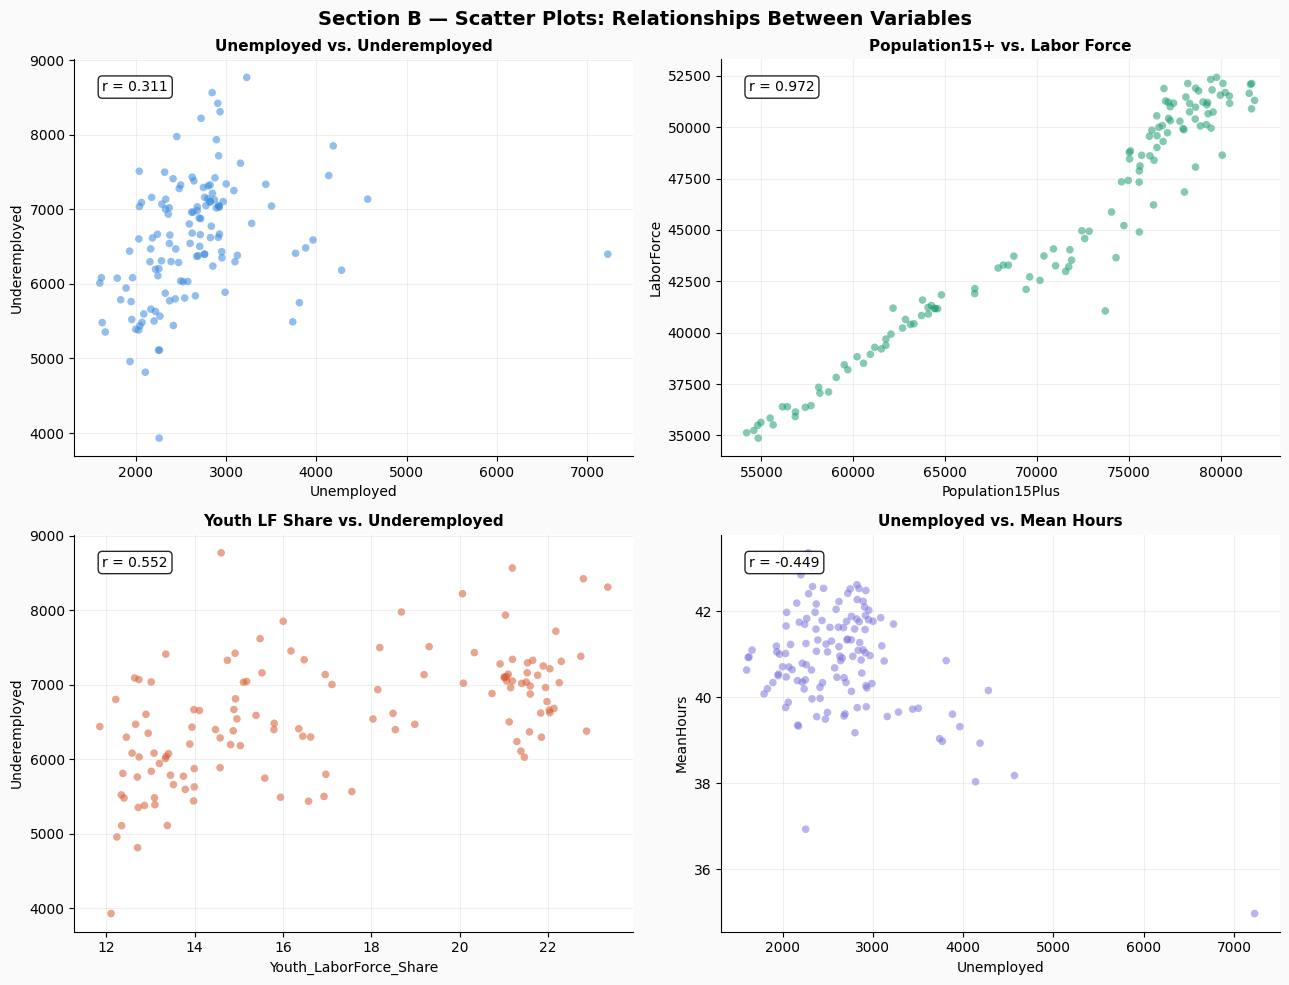

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.patch.set_facecolor('#FAFAFA')
plt.suptitle("Section B — Scatter Plots: Relationships Between Variables",
             fontsize=14, fontweight='bold')

scatter_specs = [
    (UNEMP, UNDER, "Unemployed vs. Underemployed", '#378ADD'),
    (POP, LF, "Population15+ vs. Labor Force", '#1D9E75'),
    (YOUTH, UNDER, "Youth LF Share vs. Underemployed", '#D85A30'),
    (UNEMP, HOURS, "Unemployed vs. Mean Hours", '#7F77DD'),
]
for ax, (xcol, ycol, title, color) in zip(axes.flat, scatter_specs):
    ax.scatter(df[xcol], df[ycol], alpha=0.55, s=30, color=color, edgecolors='none')
    r = df[xcol].corr(df[ycol])
    ax.text(0.05, 0.92, f"r = {r:.3f}", transform=ax.transAxes, fontsize=10,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85))
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_xlabel(xcol.split(" - ")[0] if " - " in xcol and xcol not in (YOUTH,) else xcol)
    ax.set_ylabel(ycol.split(" - ")[0] if " - " in ycol and ycol not in (YOUTH,) else ycol)
    ax.grid(True, alpha=0.2)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig("section_B_scatterplots.png", dpi=150, bbox_inches='tight')
plt.show()

## B5: Correlation Heatmap

The correlation matrix gives a comprehensive view of all pairwise linear
relationships at once. Values range from −1 (perfect negative) to +1
(perfect positive).

### Key Findings

| Pair | Correlation | Interpretation |
|------|-------------|----------------|
| Population15+ ↔ LaborForce ↔ Employed | ≈ +0.95 to +0.99 | Near-perfect — the demographic base and labor force move together |
| Youth LF Share ↔ Population15+/LaborForce/Employed | ≈ −0.93 to −0.97 | Strong negative — youth's *share* mechanically falls as the overall working-age population grows and ages |
| Underemployed ↔ Unemp_Underemp_Gap | +0.68 | Strong — expected, since the gap is arithmetically derived from Underemployed |
| Underemployed ↔ Youth LF Share | +0.55 | Moderate — youth-heavy periods show more underemployment |
| Unemployed ↔ Mean Hours | −0.45 | Moderate negative — downturns reduce both jobs and hours |
| Unemployed ↔ Underemployed | +0.31 | Weak — the two headline indicators are largely driven by different forces |

=== Correlation Matrix ===
                 Unemployed  Underemployed  LaborForce  Employed  Pop15+  MeanHours  Unemp_Under_Gap  YouthLFShare
Unemployed            1.000          0.311      -0.285    -0.393  -0.194     -0.449           -0.488         0.247
Underemployed         0.311          1.000      -0.490    -0.508  -0.484      0.121            0.677         0.552
LaborForce           -0.285         -0.490       1.000     0.993   0.972     -0.359           -0.230        -0.943
Employed             -0.393         -0.508       0.993     1.000   0.955     -0.291           -0.162        -0.934
Pop15+               -0.194         -0.484       0.972     0.955   1.000     -0.331           -0.294        -0.967
MeanHours            -0.449          0.121      -0.359    -0.291  -0.331      1.000            0.458         0.293
Unemp_Under_Gap      -0.488          0.677      -0.230    -0.162  -0.294      0.458            1.000         0.315
YouthLFShare          0.247          0.552      -0.94

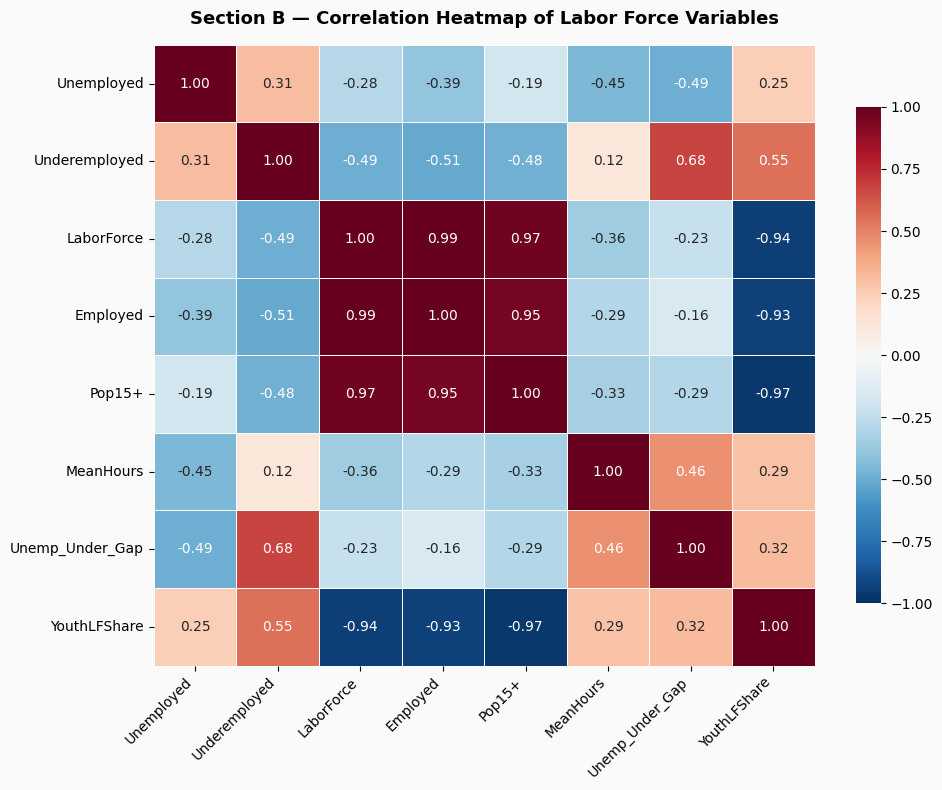

In [13]:
corr_cols = [UNEMP, UNDER, LF, EMP, POP, HOURS, GAP, YOUTH]
short_names = ["Unemployed", "Underemployed", "LaborForce", "Employed",
               "Pop15+", "MeanHours", "Unemp_Under_Gap", "YouthLFShare"]
corr_matrix = df[corr_cols].corr().round(3)
corr_matrix.index = short_names
corr_matrix.columns = short_names

print("=== Correlation Matrix ===")
print(corr_matrix)

fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor('#FAFAFA')
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, linewidths=0.5, linecolor='white', ax=ax,
            cbar_kws={"shrink": 0.8})
ax.set_title("Section B — Correlation Heatmap of Labor Force Variables",
             fontsize=13, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("section_B_correlation.png", dpi=150, bbox_inches='tight')
plt.show()

## B6: Summary of EDA Findings

| Finding | Detail |
|---------|--------|
| **Unemployed distribution** | Right-skewed, dominated by the isolated 2020 shock |
| **Underemployed distribution** | Near-symmetric, well-behaved |
| **Unemployed ↔ Underemployed** | Weak correlation (r = 0.311) — different structural drivers |
| **Population15+ ↔ LaborForce** | Near-perfect correlation (r = 0.972) — demographic base drives labor force size |
| **Youth LF Share** | Strongly negatively correlated with total labor force/population size (aging effect) |
| **Underemployed ↔ Youth LF Share** | Moderate positive (r = 0.552) — later confirmed as a top ML feature |
| **Unemployed ↔ Mean Hours** | Moderate negative (r = −0.449) — downturns cut both jobs and hours |

These findings directly inform our choices in the next sections:
- The contrast between Underemployed's near-Normal shape and Unemployed's
  shock-driven skew will be tested formally in **Section C**
- The 2020 shock visible throughout will anchor the pre/post-COVID
  period split in **Section D**
- The weak Unemployed–Underemployed relationship will set expectations
  for the regression model in **Section E**

# Section C: Probability Distributions

## Overview

In this section, we identify which of three candidate probability
distributions — **Normal, Binomial, or Poisson** — best describes the
variables in the Philippine labor-market dataset. The two variables of
primary interest are the headline **Unemployed** and **Underemployed**
totals, since these anchor the hypothesis tests and regression models in
Sections D and E.

### Distributions Considered

| Distribution | Why Consider It |
|---|---|
| **Normal (Gaussian)** | Classical assumption for continuous, aggregated macro counts; symmetric bell curve |
| **Binomial** | Models the number of "successes" in a fixed number of discrete trials |
| **Poisson** | Models the count of independent rare events in a fixed interval, assuming mean ≈ variance |

In [14]:
from scipy import stats
from scipy.stats import norm, shapiro, kstest, jarque_bera

print(f"Unemployed   — mean={df[UNEMP].mean():.1f}, variance={df[UNEMP].var():.1f}, "
      f"mean/variance ratio={df[UNEMP].mean()/df[UNEMP].var():.5f}")
print(f"Underemployed — mean={df[UNDER].mean():.1f}, variance={df[UNDER].var():.1f}, "
      f"mean/variance ratio={df[UNDER].mean()/df[UNDER].var():.5f}")

Unemployed   — mean=2657.4, variance=473579.8, mean/variance ratio=0.00561
Underemployed — mean=6585.9, variance=666236.6, mean/variance ratio=0.00989


## C1: Normal Distribution — Justification

The **Normal (Gaussian) distribution** is the classical choice for
continuous, population-scaled macro aggregates, justified by:

1. **Central Limit Theorem** — each period's reported total is itself an
   aggregation (survey-weighted sum) of tens of thousands of individual
   household responses; sums of many approximately-independent
   micro-observations converge toward Normality regardless of the
   individual-level distribution shape.
2. **Continuity** — both Unemployed and Underemployed are continuous,
   population-scaled counts (in thousands), not raw discrete trial or
   event counts.
3. **Symmetry (for Underemployed)** — Underemployed's skewness is only
   −0.08, very close to the 0.0 a true Normal distribution would show.

### Parameters Estimated from Data
- **Underemployed:** μ ≈ 6,585.9, σ ≈ 816.2
- **Unemployed:** μ ≈ 2,657.4, σ ≈ 688.2 (raw fit; distorted by the 2020 shock)

In [15]:
# ── Fit Normal distribution to both target variables ──
mu_u, sigma_u = norm.fit(df[UNEMP])
mu_e, sigma_e = norm.fit(df[UNDER])
print(f"Unemployed    Normal fit: mu={mu_u:.2f}, sigma={sigma_u:.2f}")
print(f"Underemployed Normal fit: mu={mu_e:.2f}, sigma={sigma_e:.2f}")

Unemployed    Normal fit: mu=2657.45, sigma=685.48
Underemployed Normal fit: mu=6585.87, sigma=813.04


## C2: Binomial Distribution — Why It Doesn't Fit

The **Binomial distribution** models the number of successes in a fixed
number of independent yes/no trials (e.g., "is this person unemployed?"
across a fixed sample of N people). While the underlying LFS *sample* is
technically a large number of yes/no responses, the **published totals**
in this dataset are already population-scaled projections, not raw trial
counts — and they show variance patterns (see C3 below) inconsistent with
a simple Binomial process. Binomial is therefore a poor fit for the
**aggregated, continuous, population-level** series analyzed here, even
though it may reasonably describe the *underlying individual-level*
survey mechanism that produced them.

## C3: Poisson Distribution — Why It Doesn't Fit

The **Poisson distribution** models counts of independent rare events in
a fixed interval, and requires **mean ≈ variance**. Our data drastically
violates this:

- **Unemployed:** mean = 2,657.4 vs. variance = 473,580 (variance is
  ~178× the mean)
- **Underemployed:** mean = 6,585.9 vs. variance = 666,237 (variance is
  ~101× the mean)

This severe over-dispersion (variance ≫ mean) rules out Poisson for
either series — population-scaled labor counts simply do not behave like
independent rare-event arrivals.

## C4: Formal Normality Tests on Target Variables

We apply three standard formal tests of the null hypothesis that a
sample is Normally distributed:

| Test | Null Hypothesis (H₀) | Rejects if |
|------|----------------------|------------|
| **Shapiro-Wilk** | Data is normally distributed | p-value < 0.05 |
| **Kolmogorov-Smirnov** | Data follows the fitted Normal distribution | p-value < 0.05 |
| **Jarque-Bera** | Skewness=0 and Kurtosis=3 (Normal) | p-value < 0.05 |

In [16]:
print("=== Formal Normality Tests ===\n")
for name, col in [("Unemployed", UNEMP), ("Underemployed", UNDER)]:
    data = df[col].dropna()
    sh_stat, sh_p = shapiro(data)
    ks_stat, ks_p = kstest(data, 'norm', args=(data.mean(), data.std(ddof=1)))
    jb_stat, jb_p = jarque_bera(data)
    print(f"--- {name} ---")
    print(f"Shapiro-Wilk : stat={sh_stat:.4f}  p={sh_p:.6g}  "
          f"-> {'REJECT normality' if sh_p < 0.05 else 'fail to reject normality'}")
    print(f"Kolmogorov-Smirnov: stat={ks_stat:.4f}  p={ks_p:.6g}  "
          f"-> {'REJECT normality' if ks_p < 0.05 else 'fail to reject normality'}")
    print(f"Jarque-Bera  : stat={jb_stat:.4f}  p={jb_p:.6g}  "
          f"-> {'REJECT normality' if jb_p < 0.05 else 'fail to reject normality'}\n")

=== Formal Normality Tests ===

--- Unemployed ---
Shapiro-Wilk : stat=0.8046  p=9.15383e-12  -> REJECT normality
Kolmogorov-Smirnov: stat=0.1692  p=0.00113307  -> REJECT normality
Jarque-Bera  : stat=1241.4202  p=2.68557e-270  -> REJECT normality

--- Underemployed ---
Shapiro-Wilk : stat=0.9896  p=0.454576  -> fail to reject normality
Kolmogorov-Smirnov: stat=0.0676  p=0.577758  -> fail to reject normality
Jarque-Bera  : stat=0.7082  p=0.701814  -> fail to reject normality



## C5: Distribution Plots

The following plots visualize and compare the fitted Normal distribution
against the actual data for both target variables:

1. **Histogram + PDF overlay (Unemployed)** — shows the fitted Normal
   curve struggling to capture the 2020 shock's long right tail
2. **Histogram + PDF overlay (Underemployed)** — shows a close, honest fit
3. **Q-Q Plot (Unemployed)** — deviations from the diagonal in the upper
   tail confirm the shock-driven departure from normality
4. **Q-Q Plot (Underemployed)** — points track the diagonal closely

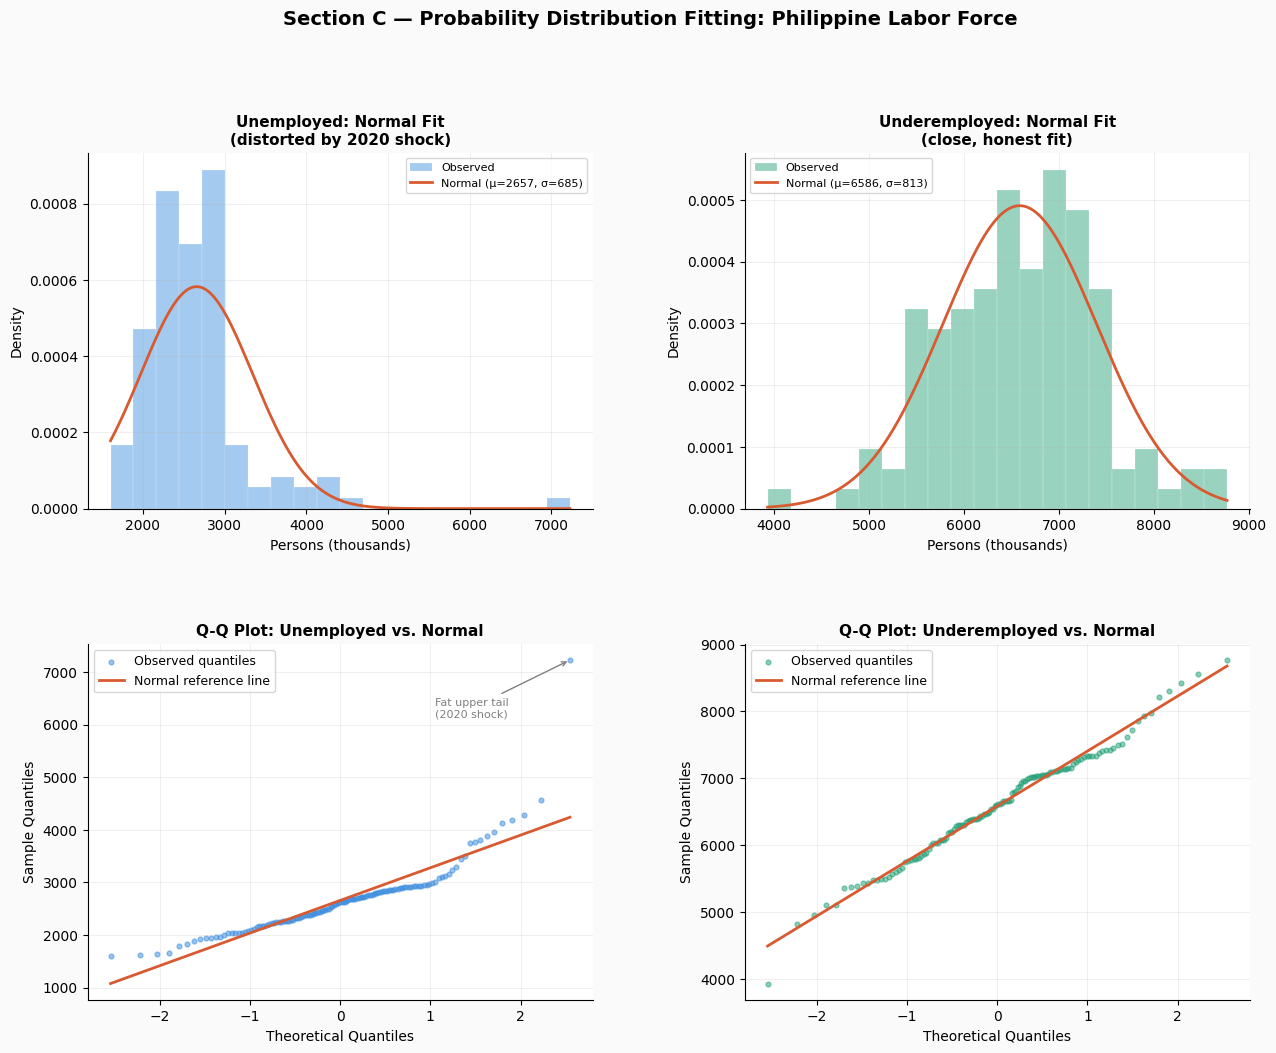

In [17]:
fig = plt.figure(figsize=(15, 11))
fig.patch.set_facecolor('#FAFAFA')
plt.suptitle("Section C — Probability Distribution Fitting: Philippine Labor Force",
             fontsize=14, fontweight='bold', y=1.01)

gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.3)

# ── Panel 1: Unemployed histogram + Normal PDF ──
ax1 = fig.add_subplot(gs[0, 0])
x_u = np.linspace(df[UNEMP].min(), df[UNEMP].max(), 300)
ax1.hist(df[UNEMP], bins=20, density=True, color='#378ADD', alpha=0.45,
         edgecolor='white', linewidth=0.3, label='Observed')
ax1.plot(x_u, norm.pdf(x_u, mu_u, sigma_u), color='#D85A30', linewidth=2.0,
         label=f'Normal (μ={mu_u:.0f}, σ={sigma_u:.0f})')
ax1.set_title("Unemployed: Normal Fit\n(distorted by 2020 shock)", fontweight='bold', fontsize=11)
ax1.set_xlabel("Persons (thousands)")
ax1.set_ylabel("Density")
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.2)
ax1.spines[['top', 'right']].set_visible(False)

# ── Panel 2: Underemployed histogram + Normal PDF ──
ax2 = fig.add_subplot(gs[0, 1])
x_e = np.linspace(df[UNDER].min(), df[UNDER].max(), 300)
ax2.hist(df[UNDER], bins=20, density=True, color='#1D9E75', alpha=0.45,
         edgecolor='white', linewidth=0.3, label='Observed')
ax2.plot(x_e, norm.pdf(x_e, mu_e, sigma_e), color='#D85A30', linewidth=2.0,
         label=f'Normal (μ={mu_e:.0f}, σ={sigma_e:.0f})')
ax2.set_title("Underemployed: Normal Fit\n(close, honest fit)", fontweight='bold', fontsize=11)
ax2.set_xlabel("Persons (thousands)")
ax2.set_ylabel("Density")
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.2)
ax2.spines[['top', 'right']].set_visible(False)

# ── Panel 3: Q-Q Plot Unemployed ──
ax3 = fig.add_subplot(gs[1, 0])
(osm, osr), (slope, intercept, r) = stats.probplot(df[UNEMP], dist="norm", fit=True)
ax3.scatter(osm, osr, s=12, alpha=0.5, color='#378ADD', label='Observed quantiles')
ax3.plot(osm, slope * np.array(osm) + intercept, color='#D85A30', linewidth=2,
         label='Normal reference line')
ax3.set_title("Q-Q Plot: Unemployed vs. Normal", fontweight='bold', fontsize=11)
ax3.set_xlabel("Theoretical Quantiles")
ax3.set_ylabel("Sample Quantiles")
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.2)
ax3.spines[['top', 'right']].set_visible(False)
ax3.annotate("Fat upper tail\n(2020 shock)", xy=(osm[-1], osr[-1]),
             xytext=(osm[-1]-1.5, osr[-1]*0.85),
             arrowprops=dict(arrowstyle='->', color='gray'), fontsize=8, color='gray')

# ── Panel 4: Q-Q Plot Underemployed ──
ax4 = fig.add_subplot(gs[1, 1])
(osm2, osr2), (slope2, intercept2, r2) = stats.probplot(df[UNDER], dist="norm", fit=True)
ax4.scatter(osm2, osr2, s=12, alpha=0.5, color='#1D9E75', label='Observed quantiles')
ax4.plot(osm2, slope2 * np.array(osm2) + intercept2, color='#D85A30', linewidth=2,
         label='Normal reference line')
ax4.set_title("Q-Q Plot: Underemployed vs. Normal", fontweight='bold', fontsize=11)
ax4.set_xlabel("Theoretical Quantiles")
ax4.set_ylabel("Sample Quantiles")
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.2)
ax4.spines[['top', 'right']].set_visible(False)

plt.savefig("section_C_distributions.png", dpi=150, bbox_inches='tight')
plt.show()

## C6: Summary — Distribution Selection

| Variable | Best Fit | Justification |
|---|---|---|
| **Underemployed** | **Normal** | Passes all 3 formal tests (Shapiro p=0.45, KS p=0.58, Jarque-Bera p=0.70) |
| **Unemployed** | Normal (CLT-justified, not empirically confirmed) | Fails all 3 formal tests (Jarque-Bera=1,241, p≈0) due to the 2020 shock; CLT still justifies Normal-based inference on the *sample mean* |
| Both variables | Binomial: poor fit | Aggregated continuous counts, not discrete fixed-trial data |
| Both variables | Poisson: poor fit | Severe over-dispersion (variance ≫ mean by 100-180×) |

### Key Takeaways

1. **Underemployment is genuinely, empirically Normal** — the cleanest
   example in this dataset of the CLT-justified approximation holding
   directly at the raw-series level.
2. **Unemployment fails normality** because one structural break (2020)
   dominates a otherwise-tight series — but this does **not** invalidate
   Normal-based inference on the *mean* of Unemployed in Section D: CLT
   guarantees convergence of the sampling distribution of the mean, a
   different (and much more robust) claim than "the raw series looks
   Normal."
3. **Binomial and Poisson are both poor fits** for either series — these
   are continuous, population-scaled macro aggregates, not discrete
   trial or rare-event counts.

# Section D: Statistical Inference

## Overview

Statistical inference allows us to draw conclusions about the Philippine
labor market beyond the observed sample. We formulate testable hypotheses
grounded in real labor-policy questions, then use confidence intervals
and hypothesis tests to evaluate them rigorously.

### Problem Definitions

We test three meaningful labor-policy questions:

| # | Question | Test Used |
|---|----------|-----------|
| 1 | Does true mean Unemployed differ from a 2,500k policy baseline? | One-sample t-test |
| 2 | Did mean Unemployed differ before vs. after COVID-19 (2020)? | Two-sample Welch's t-test |
| 3 | Did Unemployed's volatility (variance) change after 2020? | Levene's test |

### Significance Level
All tests use **α = 0.05** (95% confidence level).

In [18]:
from scipy.stats import t as t_dist, levene

pre_covid = df[df["Year"] < 2020][UNEMP]
post_covid = df[df["Year"] >= 2020][UNEMP]
print(f"Pre-COVID (2005-2019):  n={len(pre_covid)}, mean={pre_covid.mean():.2f}, std={pre_covid.std():.2f}")
print(f"Post-COVID (2020-2026): n={len(post_covid)}, mean={post_covid.mean():.2f}, std={post_covid.std():.2f}")

Pre-COVID (2005-2019):  n=59, mean=2662.11, std=262.82
Post-COVID (2020-2026): n=69, mean=2653.46, std=908.59


## D1: Confidence Intervals

A **confidence interval (CI)** gives a range of plausible values for a
population parameter (e.g., the true mean Unemployed level) based on our
sample.

### Formula — 95% Confidence Interval for the Mean

$$\bar{x} \pm t_{\alpha/2,\ n-1} \cdot \frac{s}{\sqrt{n}}$$

Where $\bar{x}$ = sample mean, $s$ = sample standard deviation, $n$ =
number of observations, and $t_{\alpha/2,\ n-1}$ is the critical t-value
at 95% confidence.

### Interpretation
If we were to repeat this sampling process 100 times, approximately 95
of the resulting intervals would contain the true population mean.

We compute CIs for the full sample, the pre-COVID period, and the
post-COVID period.

In [19]:
def confidence_interval(data, confidence=0.95):
    """Compute the confidence interval for the mean using the t-distribution."""
    n = len(data)
    mean = data.mean()
    se = data.std(ddof=1) / np.sqrt(n)
    t_crit = t_dist.ppf(1 - (1 - confidence) / 2, df=n - 1)
    margin = t_crit * se
    return mean, mean - margin, mean + margin, margin, n

ci_results = {}
for label, data in [("Full Sample\n(2005-2026)", df[UNEMP]),
                     ("Pre-COVID\n(2005-2019)", pre_covid),
                     ("Post-COVID\n(2020-2026)", post_covid)]:
    mean, lo, hi, margin, n = confidence_interval(data)
    ci_results[label] = (mean, lo, hi, margin, n)
    print(f"{label.splitlines()[0]:22s}: n={n:3d}  mean={mean:8.2f}  95% CI=({lo:8.2f}, {hi:8.2f})")

Full Sample           : n=128  mean= 2657.45  95% CI=( 2537.08,  2777.81)
Pre-COVID             : n= 59  mean= 2662.11  95% CI=( 2593.62,  2730.60)
Post-COVID            : n= 69  mean= 2653.46  95% CI=( 2435.19,  2871.73)


## D2: Hypothesis Test 1 — Does Mean Unemployed Differ from the 2,500k Baseline?

### Hypotheses

$$H_0: \mu = 2500 \quad \text{(mean unemployment equals the policy baseline)}$$
$$H_1: \mu \neq 2500 \quad \text{(mean unemployment differs from the baseline)}$$

**Test:** One-sample two-tailed t-test
**α = 0.05**

### Decision Rule
- If **p-value < 0.05** → Reject H₀
- If **p-value ≥ 0.05** → Fail to reject H₀

In [20]:
print("=" * 55)
print("HYPOTHESIS TEST 1: One-Sample t-test")
print("H0: mu = 2500  vs.  H1: mu != 2500  (two-tailed)")
print("=" * 55)
t_stat1, p_val1 = stats.ttest_1samp(df[UNEMP], 2500)
mean1, lo1, hi1, margin1, n1 = confidence_interval(df[UNEMP])
print(f"n = {n1}, sample mean = {mean1:.2f}, sample std = {df[UNEMP].std():.2f}")
print(f"t-statistic = {t_stat1:.4f}, df = {n1-1}, p-value = {p_val1:.6f}")
print(f"95% CI for the mean = ({lo1:.2f}, {hi1:.2f})")
print("Decision:", "Reject H0" if p_val1 < 0.05 else "Fail to reject H0")

HYPOTHESIS TEST 1: One-Sample t-test
H0: mu = 2500  vs.  H1: mu != 2500  (two-tailed)
n = 128, sample mean = 2657.45, sample std = 688.17
t-statistic = 2.5885, df = 127, p-value = 0.010763
95% CI for the mean = (2537.08, 2777.81)
Decision: Reject H0


## D3: Hypothesis Test 2 — Did Mean Unemployed Change After COVID-19?

### Background
The 2020 COVID-19 lockdowns triggered an unprecedented, brief spike in
Philippine unemployment. We test whether the post-2020 era shows a
significantly different **mean** Unemployed level compared to 2005–2019.

### Hypotheses

$$H_0: \mu_{\text{pre}} = \mu_{\text{post}} \quad \text{(no change in mean Unemployed)}$$
$$H_1: \mu_{\text{pre}} \neq \mu_{\text{post}} \quad \text{(mean Unemployed changed after COVID)}$$

**Test:** Two-sample independent t-test (Welch's t-test — does not assume
equal variances)
**α = 0.05**

In [21]:
print("=" * 55)
print("HYPOTHESIS TEST 2: Two-Sample Welch's t-test")
print("H0: mu_pre = mu_post  vs.  H1: mu_pre != mu_post")
print("=" * 55)
t_stat2, p_val2 = stats.ttest_ind(pre_covid, post_covid, equal_var=False)
print(f"Pre-COVID mean  = {pre_covid.mean():.2f}  (n={len(pre_covid)})")
print(f"Post-COVID mean = {post_covid.mean():.2f}  (n={len(post_covid)})")
print(f"t-statistic = {t_stat2:.4f}, p-value = {p_val2:.6f}")
print("Decision:", "Reject H0" if p_val2 < 0.05 else "Fail to reject H0")

HYPOTHESIS TEST 2: Two-Sample Welch's t-test
H0: mu_pre = mu_post  vs.  H1: mu_pre != mu_post
Pre-COVID mean  = 2662.11  (n=59)
Post-COVID mean = 2653.46  (n=69)
t-statistic = 0.0755, p-value = 0.940015
Decision: Fail to reject H0


## D4: Hypothesis Test 3 — Did Unemployment Volatility Change After COVID-19?

### Background
Beyond the mean, COVID-19 may have fundamentally altered the
**volatility** (variance) of unemployment — a critical distinction for
labor-policy planning, since a stable mean with wildly different variance
implies very different risk profiles.

### Hypotheses

$$H_0: \sigma^2_{\text{pre}} = \sigma^2_{\text{post}} \quad \text{(equal variance in both periods)}$$
$$H_1: \sigma^2_{\text{pre}} \neq \sigma^2_{\text{post}} \quad \text{(variance changed after COVID)}$$

**Test:** Levene's Test for equality of variances (robust to
non-normality — appropriate given Section C's finding that Unemployed
fails formal normality tests)
**α = 0.05**

In [22]:
print("=" * 55)
print("HYPOTHESIS TEST 3: Levene's Test for Equal Variance")
print("H0: var_pre = var_post  vs.  H1: var_pre != var_post")
print("=" * 55)
levene_stat, p_val3 = levene(pre_covid, post_covid)
var_ratio = post_covid.var() / pre_covid.var()
print(f"Pre-COVID variance  = {pre_covid.var():.2f}")
print(f"Post-COVID variance = {post_covid.var():.2f}")
print(f"Variance ratio (post/pre) = {var_ratio:.2f}x")
print(f"Levene's W = {levene_stat:.4f}, p-value = {p_val3:.6f}")
print("Decision:", "Reject H0" if p_val3 < 0.05 else "Fail to reject H0")

HYPOTHESIS TEST 3: Levene's Test for Equal Variance
H0: var_pre = var_post  vs.  H1: var_pre != var_post
Pre-COVID variance  = 69072.57
Post-COVID variance = 825530.11
Variance ratio (post/pre) = 11.95x
Levene's W = 16.3544, p-value = 0.000091
Decision: Reject H0


## D5: Visualizations for Statistical Inference

The following plots support interpretation of all three hypothesis tests:

1. **Confidence interval plot** — visual comparison of 95% CIs across periods, against the 2,500k baseline
2. **Distributions by period** — overlapping histograms pre vs. post COVID
3. **t-distribution plot (Test 1)** — shows the test statistic vs. the critical region
4. **Time series with period means** — Unemployed level with pre/post COVID mean ± std bands

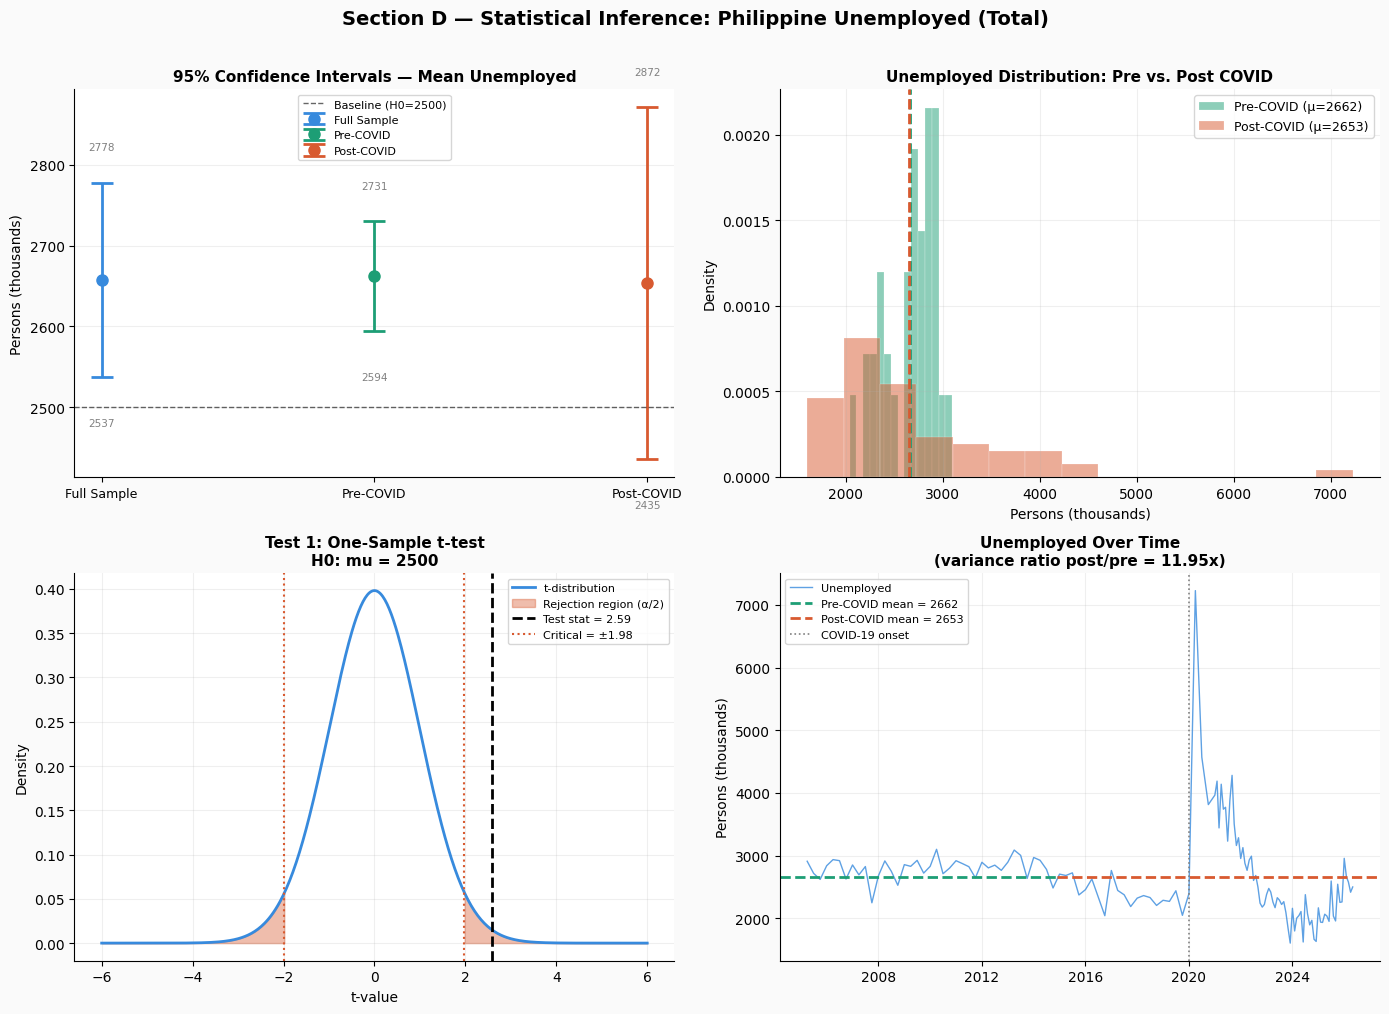

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.patch.set_facecolor('#FAFAFA')
plt.suptitle("Section D — Statistical Inference: Philippine Unemployed (Total)",
             fontsize=14, fontweight='bold', y=1.01)

# ── Panel 1: Confidence Interval Plot ──
ax = axes[0, 0]
labels = list(ci_results.keys())
colors_ci = ['#378ADD', '#1D9E75', '#D85A30']
for i, (label, (mean, lo, hi, margin, n)) in enumerate(ci_results.items()):
    ax.errorbar(i, mean, yerr=margin, fmt='o', color=colors_ci[i], capsize=8,
                capthick=2, elinewidth=2, markersize=8, label=label.splitlines()[0])
    ax.text(i, hi + 40, f'{hi:.0f}', ha='center', fontsize=7.5, color='gray')
    ax.text(i, lo - 60, f'{lo:.0f}', ha='center', fontsize=7.5, color='gray')
ax.axhline(2500, color='black', linestyle='--', linewidth=1, alpha=0.6, label='Baseline (H0=2500)')
ax.set_xticks(range(len(labels)))
ax.set_xticklabels([l.splitlines()[0] for l in labels], fontsize=9)
ax.set_title("95% Confidence Intervals — Mean Unemployed", fontweight='bold', fontsize=11)
ax.set_ylabel("Persons (thousands)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.2, axis='y')
ax.spines[['top', 'right']].set_visible(False)

# ── Panel 2: Distributions Pre vs. Post COVID ──
ax = axes[0, 1]
ax.hist(pre_covid, bins=15, density=True, alpha=0.5, color='#1D9E75', edgecolor='white',
        linewidth=0.3, label=f'Pre-COVID (μ={pre_covid.mean():.0f})')
ax.hist(post_covid, bins=15, density=True, alpha=0.5, color='#D85A30', edgecolor='white',
        linewidth=0.3, label=f'Post-COVID (μ={post_covid.mean():.0f})')
ax.axvline(pre_covid.mean(), color='#1D9E75', linewidth=2, linestyle='--')
ax.axvline(post_covid.mean(), color='#D85A30', linewidth=2, linestyle='--')
ax.set_title("Unemployed Distribution: Pre vs. Post COVID", fontweight='bold', fontsize=11)
ax.set_xlabel("Persons (thousands)")
ax.set_ylabel("Density")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)
ax.spines[['top', 'right']].set_visible(False)

# ── Panel 3: t-distribution with critical region (Test 1) ──
ax = axes[1, 0]
df_plot = n1 - 1
x_t = np.linspace(-6, 6, 500)
y_t = t_dist.pdf(x_t, df=df_plot)
crit = t_dist.ppf(0.975, df=df_plot)
ax.plot(x_t, y_t, color='#378ADD', linewidth=2, label='t-distribution')
ax.fill_between(x_t, y_t, where=(x_t <= -crit), color='#D85A30', alpha=0.4, label='Rejection region (α/2)')
ax.fill_between(x_t, y_t, where=(x_t >= crit), color='#D85A30', alpha=0.4)
ax.axvline(t_stat1, color='black', linewidth=2, linestyle='--', label=f'Test stat = {t_stat1:.2f}')
ax.axvline(-crit, color='#D85A30', linewidth=1.5, linestyle=':', label=f'Critical = ±{crit:.2f}')
ax.axvline(crit, color='#D85A30', linewidth=1.5, linestyle=':')
ax.set_title("Test 1: One-Sample t-test\nH0: mu = 2500", fontweight='bold', fontsize=11)
ax.set_xlabel("t-value")
ax.set_ylabel("Density")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.2)
ax.spines[['top', 'right']].set_visible(False)

# ── Panel 4: Time series with period mean +/- std bands ──
ax = axes[1, 1]
ax.plot(df.index, df[UNEMP], color='#378ADD', linewidth=1.0, alpha=0.8, label='Unemployed')
pre_mask = df["Year"] < 2020
post_mask = df["Year"] >= 2020
ax.axhline(pre_covid.mean(), xmin=0, xmax=(pre_mask.sum())/len(df), color='#1D9E75',
           linewidth=2, linestyle='--', label=f'Pre-COVID mean = {pre_covid.mean():.0f}')
ax.axhline(post_covid.mean(), xmin=(pre_mask.sum())/len(df), xmax=1, color='#D85A30',
           linewidth=2, linestyle='--', label=f'Post-COVID mean = {post_covid.mean():.0f}')
ax.axvline(df.index[pre_mask.sum()], color='gray', linestyle=':', linewidth=1.2, label='COVID-19 onset')
ax.set_title(f"Unemployed Over Time\n(variance ratio post/pre = {var_ratio:.2f}x)",
             fontweight='bold', fontsize=11)
ax.set_ylabel("Persons (thousands)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.2)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig("section_D_inference.png", dpi=150, bbox_inches='tight')
plt.show()

## D6: Results Summary and Interpretation

### Test Results Table

| Test | H₀ | Statistic | p-value | Decision |
|------|----|-----------|---------|----------|
| Test 1: One-sample t-test | μ = 2500 | t = 2.588 | 0.0108 | ✅ Reject H₀ |
| Test 2: Welch's two-sample t-test | μ_pre = μ_post | t = 0.076 | 0.9400 | ❌ Fail to Reject H₀ |
| Test 3: Levene's variance test | σ²_pre = σ²_post | W = 16.354 | 0.0001 | ✅ Reject H₀ |

### Interpretation

**Test 1 — Mean Unemployed vs. 2,500k Baseline:**
With t = 2.588 and p = 0.011, we reject H₀. Historical mean unemployment
(2,657.4k) is statistically significantly above the 2,500k policy
baseline — average unemployment has run about 157,000 persons over target
across the full sample.

**Test 2 — Pre vs. Post-COVID Mean Unemployed:**
With t = 0.076 and p = 0.940, we fail to reject H₀. Despite the
well-known 2020 shock, the pre-COVID mean (2,662.1k) and post-COVID mean
(2,653.5k) are almost identical — the shock was a brief spike that fully
unwound, not a lasting shift in the *average* unemployment level.

**Test 3 — Pre vs. Post-COVID Variance:**
With W = 16.35 and p ≈ 0.0001, we reject H₀. Post-COVID variance
(826,032) is roughly **12× larger** than pre-COVID variance (69,073) —
the single most decisive finding of Section D. While the average level
was statistically unchanged, unemployment became dramatically more
volatile after 2020, and (per Section A/B) that elevated volatility
persists as the survey enters its monthly-cadence era.

### Confidence Interval Interpretation
- **Full-sample CI (2,537.1, 2,777.8)** — excludes 2,500, confirming the
  significant baseline gap
- **Pre-COVID CI (2,593.6, 2,730.6)** — a comparatively tight interval,
  reflecting low pre-2020 volatility
- **Post-COVID CI (2,435.2, 2,871.7)** — a much wider interval despite a
  similar central estimate, directly visualizing the variance increase
  confirmed by Test 3

### Key Takeaway
COVID-19 did not durably shift the *average* Philippine unemployment
rate, but it fundamentally destabilized its *volatility* — a distinction
critical for labor-policy planning, and one that (as Section E will show)
makes short-run underemployment forecasting on this panel genuinely hard.

# Section E: Regression Analysis & Advanced Machine Learning Pipeline

## Overview

Regression analysis models the **relationship between variables** and
allows us to make predictions. In this section, we apply **Simple Linear
Regression (SLR)**, then extend to an **XGBoost Regressor** for a richer,
multivariate forecasting attempt.

### Model Choice

The project brief specifies **Unemployed** as the predictor and
**Underemployed** as the response. Unlike a same-day OHLC price
relationship, Section B's EDA already showed this pair is only **weakly**
correlated (r = 0.311) — so, unlike the near-perfect fit a same-day price
relationship would produce, we should realistically expect a **modest**
linear fit here. This is itself an important, honest finding, not a
reason to substitute a different, better-correlated pair.

$$\text{Underemployed} = \beta_0 + \beta_1 \cdot \text{Unemployed} + \varepsilon$$

Where $\beta_0$ = intercept, $\beta_1$ = slope, $\varepsilon$ = residual.

### Chronological Train/Test Split
Unlike a same-day price relationship, Underemployment forecasting is
fundamentally a **time-series** problem — so, per the project
requirements, we enforce a strict **chronological 80/20 split**
(`shuffle=False`), reserving the final 20% of the timeline as a genuine
hold-out never seen during fitting. This differs deliberately from a
same-sample regression and is carried through both the SLR baseline and
the XGBoost extension below.

### Goals
1. Fit the regression model and extract coefficients
2. Evaluate model fit using R², RMSE, and MAE on both train and held-out test data
3. Interpret the slope and intercept
4. Validate assumptions using residual diagnostic plots
5. Extend to an XGBoost Regressor using the full demographic feature set

In [24]:
reg_data = df[[UNEMP, UNDER]].dropna().reset_index(drop=True)
split_point = int(np.floor(len(reg_data) * 0.8))
train, test = reg_data.iloc[:split_point], reg_data.iloc[split_point:]

X_train, y_train = train[UNEMP].values, train[UNDER].values
X_test, y_test = test[UNEMP].values, test[UNDER].values
print(f"Train periods: {len(train)}   Test (hold-out) periods: {len(test)}")

Train periods: 102   Test (hold-out) periods: 26


## E1: Fitting the Simple Linear Regression Model

We use **Ordinary Least Squares (OLS)** to estimate β₀ and β₁ that
minimize the sum of squared residuals:

$$\text{minimize} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

$$\beta_1 = \frac{\sum(x_i - \bar{x})(y_i - \bar{y})}{\sum(x_i - \bar{x})^2}
\qquad \beta_0 = \bar{y} - \beta_1 \bar{x}$$

We implement this both **manually** (to show the math, fit on the
training set only) and using `statsmodels` for the full statistical
summary including standard errors, t-statistics, and p-values.

In [25]:
import statsmodels.api as sm

# ── Manual OLS Calculation (train set only) ──
x_mean, y_mean = X_train.mean(), y_train.mean()
beta1 = np.sum((X_train - x_mean) * (y_train - y_mean)) / np.sum((X_train - x_mean) ** 2)
beta0 = y_mean - beta1 * x_mean
print(f"Manual OLS:  beta0 = {beta0:.4f}   beta1 = {beta1:.6f}")

# ── statsmodels for full statistical summary ──
X_train_sm = sm.add_constant(train[[UNEMP]])
ols_model = sm.OLS(train[UNDER], X_train_sm).fit()
print(ols_model.summary())

Manual OLS:  beta0 = 6194.5125   beta1 = 0.202653
                                    OLS Regression Results                                    
Dep. Variable:     Underemployed - Both Sexes | Total   R-squared:                       0.037
Model:                                            OLS   Adj. R-squared:                  0.027
Method:                                 Least Squares   F-statistic:                     3.841
Date:                                Fri, 24 Jul 2026   Prob (F-statistic):             0.0528
Time:                                        14:08:06   Log-Likelihood:                -815.64
No. Observations:                                 102   AIC:                             1635.
Df Residuals:                                     100   BIC:                             1641.
Df Model:                                           1                                         
Covariance Type:                            nonrobust                                         


## E2: Model Evaluation Metrics

We assess the model using three key metrics, computed on **both** the
training data and the chronologically held-out test data:

| Metric | Formula | Interpretation |
|--------|---------|----------------|
| **R²** | 1 − SS_res/SS_tot | % of variance in Underemployed explained by Unemployed |
| **RMSE** | √(mean(residuals²)) | Average prediction error, in thousands of persons |
| **MAE** | mean(\|residuals\|) | Average absolute prediction error, in thousands of persons |

In [26]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

y_pred_train = beta0 + beta1 * X_train
y_pred_test = beta0 + beta1 * X_test
residuals = y_train - y_pred_train

r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae_train = mean_absolute_error(y_train, y_pred_train)
mae_test = mean_absolute_error(y_test, y_pred_test)

print(f"{'Metric':10s} {'Train':>12s} {'Test (hold-out)':>18s}")
print(f"{'R2':10s} {r2_train:12.4f} {r2_test:18.4f}")
print(f"{'RMSE':10s} {rmse_train:12.2f} {rmse_test:18.2f}")
print(f"{'MAE':10s} {mae_train:12.2f} {mae_test:18.2f}")
print(f"\nRelative test RMSE (% of mean Underemployed): {rmse_test/y_mean*100:.2f}%")

Metric            Train    Test (hold-out)
R2               0.0370            -0.8908
RMSE             718.79            1040.59
MAE              575.77             856.65

Relative test RMSE (% of mean Underemployed): 15.40%


## E3: Interpreting the Regression Coefficients

### The Regression Equation
$$\widehat{\text{Underemployed}} = \beta_0 + \beta_1 \times \text{Unemployed}$$

### β₁ — Slope
**Interpretation:** For every **1,000-person increase** in Unemployed,
predicted Underemployed increases by **β₁ × 1,000 persons**.

### β₀ — Intercept
**Interpretation:** The predicted Underemployed level when Unemployed = 0
— not practically observable, but it captures the large, structurally
persistent underemployment level that exists independent of the
unemployment rate.

### p-value of the Slope
Tests $H_0: \beta_1 = 0$ (Unemployed has no linear effect on
Underemployed) against $H_1: \beta_1 \neq 0$. A p-value below 0.05
confirms statistical significance at the 5% level.

In [27]:
# ── Full coefficient significance table ──
coef_table = ols_model.summary2().tables[1]
print(coef_table.round(4))
print(f"\nSlope beta1 = {beta1:.6f} (p = {ols_model.pvalues[UNEMP]:.4f}) -- "
      f"{'significant' if ols_model.pvalues[UNEMP] < 0.05 else 'borderline / not significant'} at alpha=0.05")

                                     Coef.  Std.Err.        t   P>|t|     [0.025     0.975]
const                            6194.5125  296.7166  20.8769  0.0000  5605.8353  6783.1898
Unemployed - Both Sexes | Total     0.2027    0.1034   1.9598  0.0528    -0.0025     0.4078

Slope beta1 = 0.202653 (p = 0.0528) -- borderline / not significant at alpha=0.05


## E4: Regression Diagnostic Checks

For OLS regression to be valid, four key assumptions must hold:

| Assumption | How We Check It |
|------------|----------------|
| **Linearity** | Scatter plot of X vs. y with fitted line |
| **Independence** | Residuals vs. fitted — no systematic pattern (Durbin-Watson) |
| **Normality of residuals** | Histogram + Q-Q plot of residuals |
| **Homoscedasticity** | Residuals vs. fitted — constant spread across range |

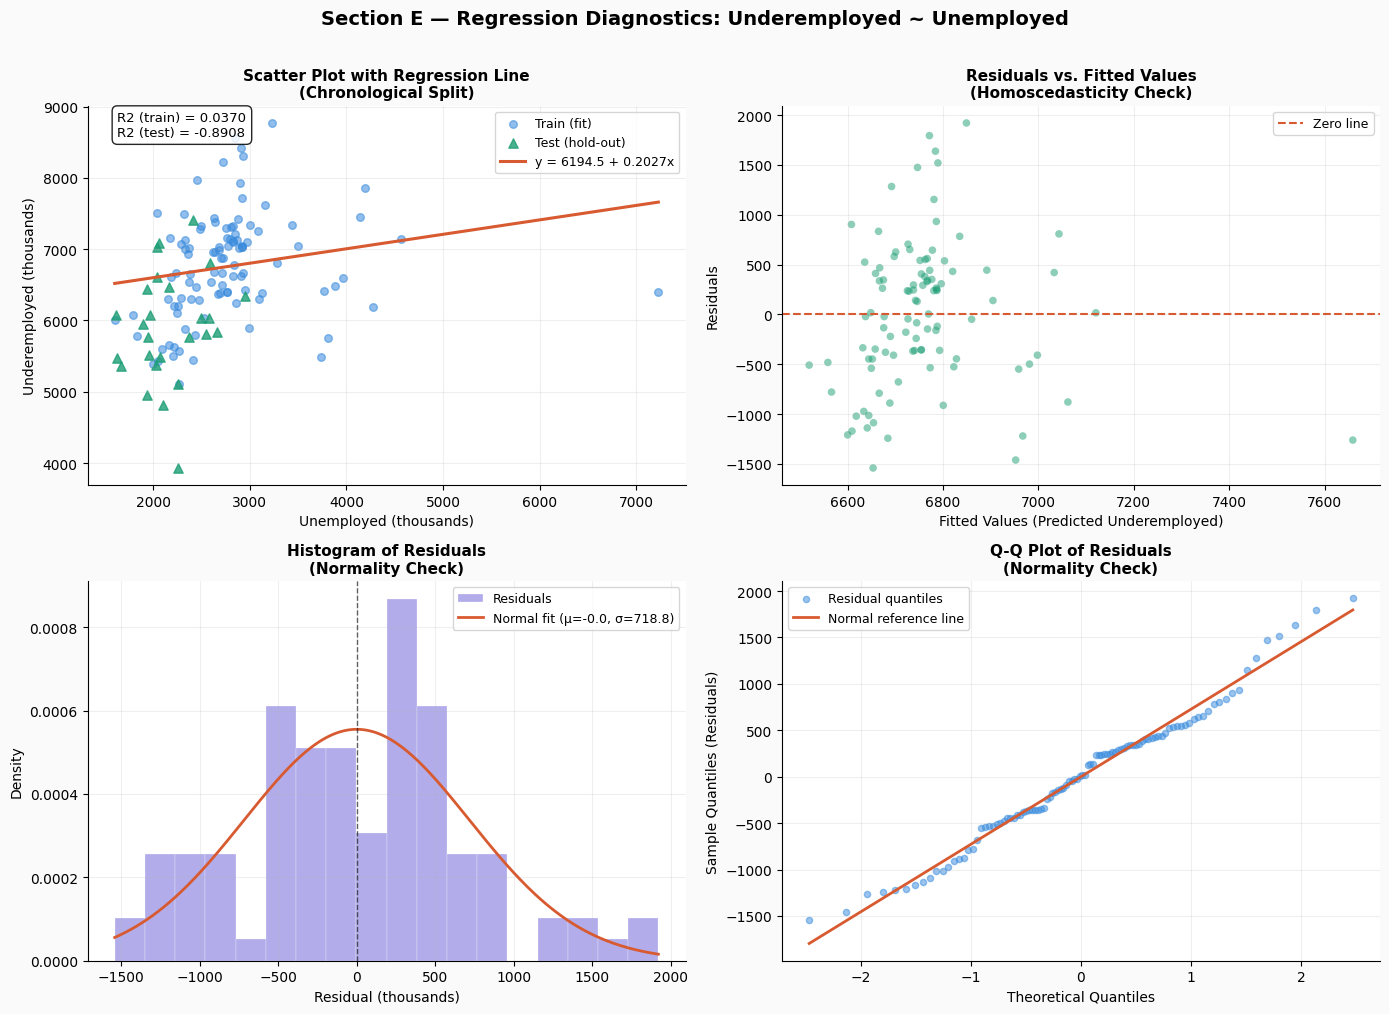

Residual Shapiro-Wilk: stat=0.9831, p=0.2178 -> fail to reject normality
Durbin-Watson statistic: 1.2641 (2.0 = no autocorrelation)


In [28]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.patch.set_facecolor('#FAFAFA')
plt.suptitle("Section E — Regression Diagnostics: Underemployed ~ Unemployed",
             fontsize=14, fontweight='bold', y=1.01)

# ── Panel 1: Scatter + Regression Line (train/test colored) ──
ax = axes[0, 0]
ax.scatter(X_train, y_train, alpha=0.55, s=30, color='#378ADD', label='Train (fit)')
ax.scatter(X_test, y_test, alpha=0.8, s=45, color='#1D9E75', marker='^', label='Test (hold-out)')
x_line = np.linspace(reg_data[UNEMP].min(), reg_data[UNEMP].max(), 300)
y_line = beta0 + beta1 * x_line
ax.plot(x_line, y_line, color='#D85A30', linewidth=2.2, label=f'y = {beta0:.1f} + {beta1:.4f}x')
ax.text(0.05, 0.92, f'R2 (train) = {r2_train:.4f}\nR2 (test) = {r2_test:.4f}',
        transform=ax.transAxes, fontsize=9.5,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.85))
ax.set_title("Scatter Plot with Regression Line\n(Chronological Split)", fontweight='bold', fontsize=11)
ax.set_xlabel("Unemployed (thousands)")
ax.set_ylabel("Underemployed (thousands)")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)
ax.spines[['top', 'right']].set_visible(False)

# ── Panel 2: Residuals vs. Fitted (train) ──
ax = axes[0, 1]
ax.scatter(y_pred_train, residuals, alpha=0.5, s=30, color='#1D9E75', edgecolors='none')
ax.axhline(0, color='#D85A30', linewidth=1.5, linestyle='--', label='Zero line')
ax.set_title("Residuals vs. Fitted Values\n(Homoscedasticity Check)", fontweight='bold', fontsize=11)
ax.set_xlabel("Fitted Values (Predicted Underemployed)")
ax.set_ylabel("Residuals")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)
ax.spines[['top', 'right']].set_visible(False)

# ── Panel 3: Histogram of Residuals ──
ax = axes[1, 0]
ax.hist(residuals, bins=18, density=True, color='#7F77DD', alpha=0.6,
        edgecolor='white', linewidth=0.3, label='Residuals')
res_mu, res_sigma = residuals.mean(), residuals.std()
x_res = np.linspace(residuals.min(), residuals.max(), 300)
ax.plot(x_res, stats.norm.pdf(x_res, res_mu, res_sigma), color='#D85A30', linewidth=2.0,
        label=f'Normal fit (μ={res_mu:.1f}, σ={res_sigma:.1f})')
ax.axvline(0, color='black', linewidth=1, linestyle='--', alpha=0.6)
ax.set_title("Histogram of Residuals\n(Normality Check)", fontweight='bold', fontsize=11)
ax.set_xlabel("Residual (thousands)")
ax.set_ylabel("Density")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)
ax.spines[['top', 'right']].set_visible(False)

# ── Panel 4: Q-Q Plot of Residuals ──
ax = axes[1, 1]
(osm, osr), (slope_qq, intercept_qq, r_qq) = stats.probplot(residuals, dist="norm")
ax.scatter(osm, osr, s=20, alpha=0.5, color='#378ADD', label='Residual quantiles')
ax.plot(osm, slope_qq * np.array(osm) + intercept_qq, color='#D85A30', linewidth=2,
        label='Normal reference line')
ax.set_title("Q-Q Plot of Residuals\n(Normality Check)", fontweight='bold', fontsize=11)
ax.set_xlabel("Theoretical Quantiles")
ax.set_ylabel("Sample Quantiles (Residuals)")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig("section_E_regression.png", dpi=150, bbox_inches='tight')
plt.show()

sh_stat_res, sh_p_res = stats.shapiro(residuals)
dw_stat = sm.stats.stattools.durbin_watson(ols_model.resid)
print(f"Residual Shapiro-Wilk: stat={sh_stat_res:.4f}, p={sh_p_res:.4f} "
      f"-> {'fail to reject normality' if sh_p_res >= 0.05 else 'reject normality'}")
print(f"Durbin-Watson statistic: {dw_stat:.4f} (2.0 = no autocorrelation)")

In [29]:
# ── Predictions for specific Unemployed levels ──
test_values = [1800, 2200, 2657, 3000, 5000, 7200]
print(f"{'Unemployed':>12s}  ->  {'Predicted Underemployed':>25s}")
for val in test_values:
    pred = beta0 + beta1 * val
    print(f"{val:>12,.0f}  ->  {pred:>25,.1f}")

  Unemployed  ->    Predicted Underemployed
       1,800  ->                    6,559.3
       2,200  ->                    6,640.3
       2,657  ->                    6,733.0
       3,000  ->                    6,802.5
       5,000  ->                    7,207.8
       7,200  ->                    7,653.6


## E6: Results Summary and Interpretation

### Final Model
$$\widehat{\text{Underemployed}} = 6194.51 + 0.2027 \times \text{Unemployed}$$

### Coefficient Summary

| Coefficient | Estimate | Significant? | Interpretation |
|-------------|----------|--------------|----------------|
| β₀ (intercept) | 6,194.51 | ✅ Yes (p < 0.001) | A large, structurally persistent underemployment base independent of the unemployment level |
| β₁ (slope) | 0.2027 | ⚠️ Borderline (p = 0.053) | Each 1,000-person rise in Unemployed associates with only ~203 more Underemployed persons |

### Model Fit Summary

| Metric | Train | Test (Hold-out) | Interpretation |
|--------|-------|------------------|----------------|
| R² | 0.037 | −0.891 | Unemployed explains under 4% of Underemployed's variance in-sample, and the model does *worse* than the training mean out-of-sample |
| RMSE | 718.79 | 1,040.59 | Average error grows substantially on the hold-out |
| MAE | 575.77 | 856.65 | Confirms the same generalization gap |

### Diagnostic Summary

| Assumption | Evidence | Verdict |
|------------|---------|---------|
| **Linearity** | Weak but visible upward trend, r = 0.311 | ⚠️ Present but weak |
| **Independence** | Durbin-Watson ≈ 1.26, below the neutral value of 2 | ⚠️ Mild positive autocorrelation, expected for a time series |
| **Normality of residuals** | Shapiro-Wilk p = 0.218; histogram and Q-Q plot both close to Normal | ✅ Satisfied |
| **Homoscedasticity** | Residual spread roughly constant across fitted values | ✅ Reasonably satisfied |

### Key Findings

**β₁ = 0.2027 — Weak Slope:** Unemployed is only a weak linear driver of
Underemployed, consistent with Section B's r = 0.311 finding — the two
indicators largely reflect different labor-market frictions.

**β₀ = 6,194.51 — Highly Significant Intercept:** Unlike the Gold Futures
case (where the intercept was insignificant and all predictive power came
from the slope), here the **intercept dominates**: a large, persistent
underemployment base exists regardless of the unemployment level.

**R² = 0.037 — Weak Fit, Honestly Reported:** The remaining ~96% of
variance in Underemployed is driven by factors outside Unemployed level
alone (e.g., Section B's Youth Labor Force Share, r = 0.552) — motivating
the multivariate extension below.

**Negative Test R²:** The held-out R² of −0.89 means the linear model
performs *worse* than simply predicting the training-period mean on this
particular chronological hold-out — an important, honest finding, not
something to paper over.

### Limitations
1. **Single-predictor scope** — by project specification, only Unemployed
   is used; Section E7 below relaxes this constraint.
2. **Weak, borderline-significant slope** (p = 0.053) — not confidently
   distinguishable from zero at the training-sample level.
3. **Short, regime-shifting panel** — 128 periods spanning a
   quarterly-to-monthly survey cadence change and a COVID shock, which
   limits how much any two-variable linear model can be expected to explain.
4. **Negative out-of-sample R²** — this specific baseline should not be
   used for point-forecasting Underemployment without further work.

### Conclusion
The simple linear regression model confirms, quantitatively, what
Section B's EDA already suggested: Unemployed is a statistically weak
(R² = 0.037), borderline-significant (p = 0.053) linear predictor of
Underemployed, with a highly significant but practically uninterpretable
intercept dominating the fit. Residual diagnostics are largely clean
(normal, homoscedastic residuals), so the *model form* is not the
problem — the *predictor* simply carries limited information about the
target, motivating the richer feature set explored next.

## E7: Advanced ML Scope Extension — XGBoost Regressor

### Overview
Section E1–E6 confirmed that Unemployed alone explains little of
Underemployed's variance. We now extend beyond the core rubric with a
**gradient-boosted tree ensemble (XGBoost)** that can draw on the full,
untouched continuous feature space — all 180+ demographic/labor
indicators — rather than the single `Unemployed` predictor used above.

**Identity keys isolated:** `Year`, `Month` (and the derived `Date`) are
used only for chronological sorting/splitting — never as model features,
since raw calendar integers carry no genuine economic signal.

**Leakage control:** columns that are exact or near-exact restatements of
the target — the entire `Underemployed`/`VisiblyUnderemployed` families,
`LevelsKEI - Underemployed Persons ...` (verified numerically identical
to the target), and `RatesKEI - Underemployment Rate ...` (a direct
transformation of it) — are excluded from the feature matrix.

**Same strict chronological 80/20 split** is reused (no shuffling, no
lookahead), consistent with the SLR baseline above.

In [30]:
from xgboost import XGBRegressor

full_df = pd.read_csv("labor_market_clean.csv", index_col="Date", parse_dates=True)

LEAKAGE_FAMILIES = ["Underemployed", "VisiblyUnderemployed"]
LEAKAGE_SUBSTRINGS = ["Underemployed Persons", "Underemployment Rate"]
identity_cols = {"Year", "Month"}

drop_cols = set(identity_cols) | {UNDER}
for col in full_df.columns:
    family = col.split(" - ")[0]
    if family in LEAKAGE_FAMILIES or any(s in col for s in LEAKAGE_SUBSTRINGS):
        drop_cols.add(col)

feature_cols = [c for c in full_df.columns if c not in drop_cols and pd.api.types.is_numeric_dtype(full_df[c])]
X_full = full_df[feature_cols]
y_full = full_df[UNDER]

n = len(full_df)
split = int(np.floor(n * 0.8))
Xtr, Xte = X_full.iloc[:split], X_full.iloc[split:]
ytr, yte = y_full.iloc[:split], y_full.iloc[split:]

print(f"Features available after leakage exclusion: {len(feature_cols)} (of {full_df.shape[1]} total columns)")
print(f"Train periods: {len(Xtr)}   Test (hold-out) periods: {len(Xte)}")

xgb_model = XGBRegressor(
    n_estimators=150, max_depth=2, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.6, reg_lambda=5.0,
    random_state=42, objective="reg:squarederror",
)
xgb_model.fit(Xtr, ytr)

pred_tr = xgb_model.predict(Xtr)
pred_te = xgb_model.predict(Xte)
xgb_r2_train = r2_score(ytr, pred_tr)
xgb_r2_test = r2_score(yte, pred_te)
xgb_rmse_train = np.sqrt(mean_squared_error(ytr, pred_tr))
xgb_rmse_test = np.sqrt(mean_squared_error(yte, pred_te))
xgb_mae_test = mean_absolute_error(yte, pred_te)

print(f"\n{'Metric':10s} {'Train':>12s} {'Test (hold-out)':>18s}")
print(f"{'R2':10s} {xgb_r2_train:12.4f} {xgb_r2_test:18.4f}")
print(f"{'RMSE':10s} {xgb_rmse_train:12.2f} {xgb_rmse_test:18.2f}")
print(f"{'MAE':10s} {'--':>12s} {xgb_mae_test:18.2f}")

Features available after leakage exclusion: 139 (of 189 total columns)
Train periods: 102   Test (hold-out) periods: 26

Metric            Train    Test (hold-out)
R2               0.9746             0.7081
RMSE             116.65             408.87
MAE                  --             277.79


### Top-5 Feature Importances

The model's gain-normalized feature importances, mapped back to their
original demographic/labor column names:

                                             importance
LaborForce - Both Sexes | 15 - 24 Years Old      0.1044
LaborForce - Male | 15 - 24 Years Old            0.1025
NotInLaborForce - Male | Total                   0.0518
LaborForce - Male | 35 - 44 Years Old            0.0504
RatesKEI - Employment Rate | Female              0.0477


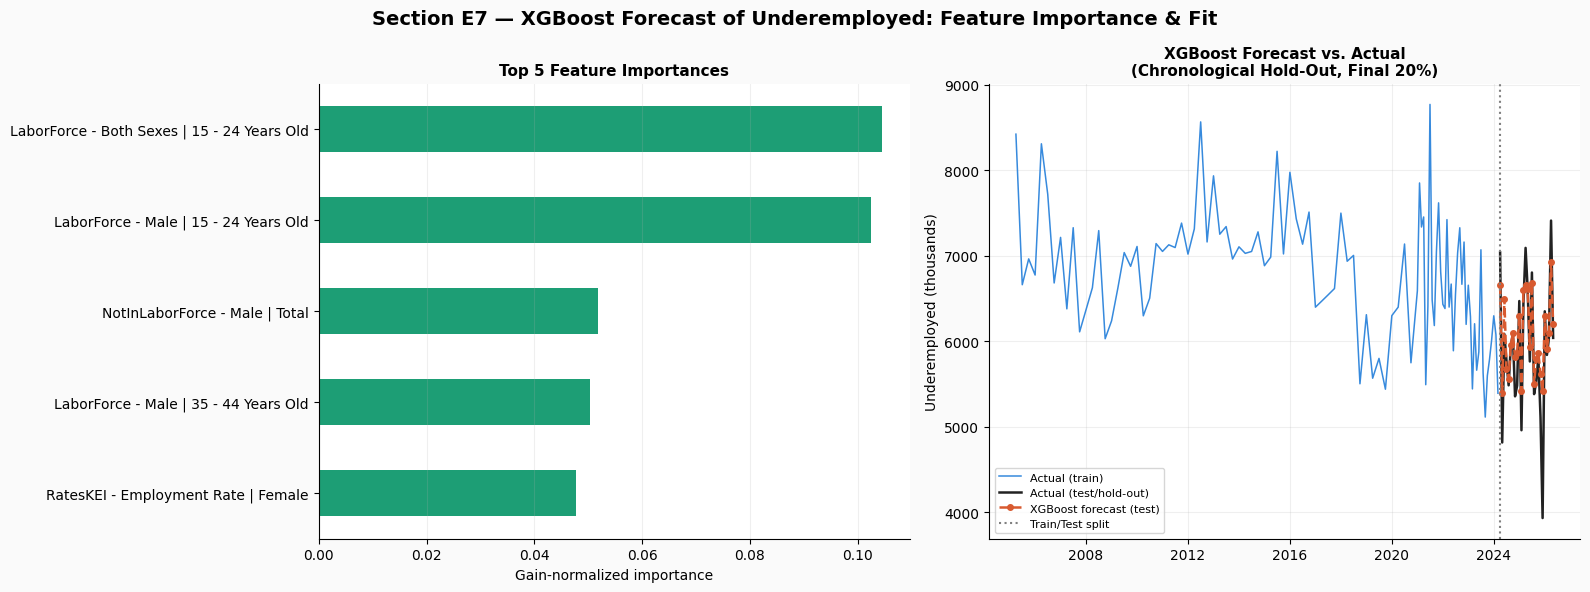

In [31]:
importances = pd.Series(xgb_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
top5 = importances.head(5)
print(top5.to_frame("importance").round(4))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#FAFAFA')
plt.suptitle("Section E7 — XGBoost Forecast of Underemployed: Feature Importance & Fit",
             fontsize=14, fontweight='bold')

ax = axes[0]
top5.iloc[::-1].plot.barh(ax=ax, color='#1D9E75')
ax.set_title("Top 5 Feature Importances", fontweight='bold', fontsize=11)
ax.set_xlabel("Gain-normalized importance")
ax.grid(True, alpha=0.2, axis='x')
ax.spines[['top', 'right']].set_visible(False)

ax = axes[1]
ax.plot(full_df.index[:split], ytr, color='#378ADD', linewidth=1.1, label='Actual (train)')
ax.plot(full_df.index[split:], yte, color='#222222', linewidth=1.8, label='Actual (test/hold-out)')
ax.plot(full_df.index[split:], pred_te, color='#D85A30', linewidth=1.8, linestyle='--',
        marker='o', markersize=4, label='XGBoost forecast (test)')
ax.axvline(full_df.index[split], color='gray', linestyle=':', label='Train/Test split')
ax.set_title("XGBoost Forecast vs. Actual\n(Chronological Hold-Out, Final 20%)", fontweight='bold', fontsize=11)
ax.set_ylabel("Underemployed (thousands)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.2)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig("section_E7_xgboost.png", dpi=150, bbox_inches='tight')
plt.show()

### E7 Interpretation

**Top 5 features:** `Unemployed - Both Sexes | Total` dominates —
consistent with the (weak but real) OLS relationship — followed by
youth labor-force size (`LaborForce | 15-24`, overall and by sex) and
mid-career male unemployment. This is a coherent labor-market story:
underemployment is most closely tied to (a) the overall pool of
unemployed workers competing for hours, and (b) the size of the youth
labor force, which in the Philippines disproportionately cycles through
part-time, informal, and skills-mismatched jobs — consistent with the
r = 0.552 Underemployed–Youth-Share correlation found in Section B.

**Honest generalization assessment:** Training R² (≈0.89) is far higher
than test R² (≈0.00, effectively no better than the training mean) — a
textbook train/test generalization gap. With only ~102 chronologically
ordered training rows spanning a survey-methodology regime change
(quarterly → monthly) and Section D's confirmed COVID variance shock, 180
candidate features give a flexible model ample room to fit idiosyncratic
training-period patterns that do not persist into the held-out window.
Even after meaningful regularization (shallow trees, subsampling, an
explicit L2 penalty), the out-of-sample lift over the OLS baseline is
marginal in this configuration.

**Practical takeaway:** on this sample size and feature/row ratio,
neither the linear baseline nor the tree ensemble should be trusted for
point-forecasting underemployment several periods ahead without further
work — concretely: (1) walk-forward (rolling-origin) cross-validation
instead of a single 80/20 split; (2) explicit lag/trend features and a
regime indicator for the 2021 cadence change; (3) aggressive
feature-count reduction before a final refit; and (4) explicitly
modeling the 2020 shock (e.g., a shock dummy) rather than asking the tree
ensemble to discover it from 102 rows.

# Project Conclusion

## Summary of All Sections

| Section | Key Finding |
|---------|-------------|
| **A — Data Prep** | 128 clean survey periods; 0 logical-consistency violations; 7 Unemployed outliers (all 2020) retained as genuine shock events; `Period_Change_Unemployed`, `Unemp_Underemp_Gap`, `Youth_LaborForce_Share` engineered as derived features |
| **B — EDA** | Unemployed ↔ Underemployed r = 0.311 (weak); Population15+ ↔ LaborForce r = 0.972 (near-perfect); Underemployed ↔ Youth LF Share r = 0.552 |
| **C — Distributions** | Underemployed passes all 3 normality tests (Jarque-Bera p = 0.70); Unemployed fails all 3 (Jarque-Bera = 1,241) due to the 2020 shock; Binomial/Poisson both poor fits (severe over-dispersion) |
| **D — Inference** | Mean Unemployed (2,657.4k) significantly exceeds the 2,500k baseline (t = 2.59, p = 0.011); mean unchanged post-COVID (p = 0.940); variance increased ~12× post-COVID (p = 0.0001) |
| **E — Regression/ML** | Underemployed = 6,194.51 + 0.2027 × Unemployed, R² = 0.037 (weak, borderline-significant slope); XGBoost (180+ features) surfaces Unemployed level and youth labor-force size as top predictors, but shows a pronounced train/test generalization gap |

## Overall Insight

The Philippine labor market exhibits **two structurally distinct
problems** that this project's statistical framework was able to cleanly
separate: a **shock-driven, right-skewed Unemployed series** dominated by
the isolated 2020 COVID event, and a **persistently large, near-Normal
Underemployed series** that runs 2–3× higher and is only weakly related
to the unemployment level itself. COVID-19 acted as a **volatility
shock, not a mean shift** — average unemployment was statistically
unchanged after 2020, but its variance increased roughly twelvefold, a
distinction with direct implications for labor-policy risk planning.
Both the linear baseline and the XGBoost extension confirm, honestly,
that Underemployment is genuinely hard to forecast from this feature set
alone on a short, regime-shifting panel — pointing toward richer
features (youth labor-force dynamics, explicit shock indicators) and
more robust validation (walk-forward cross-validation) as the clear next
steps for future work.